# Explainable Fraud Detection in FinTech Using Fine-Tuned Large Language Models: An ISO 42001-Aligned AIBOM Approach
Five phases: baseline classifier, SHAP attribution, serialisation, QLoRA
fine-tuning, faithfulness evaluation. Intermediate artefacts are cached to disk
so later phases can be re-run without repeating the expensive steps.

In [1]:
#1
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM (GB):", torch.cuda.get_device_properties(0).total_memory / 1e9)

CUDA available: True
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
VRAM (GB): 8.546484224


In [ ]:
#2
import re
import pandas as pd
import numpy as np
import json
import random
import os
import sys
import pickle
import time
import ast
import optuna
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches, Rectangle
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, average_precision_score, f1_score
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, TrainingArguments, Trainer, DataCollatorForLanguageModeling
from huggingface_hub import whoami
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel
from datasets import Dataset


## Phase 1: Data preparation
Join the transaction and identity tables, sort by TransactionDT, split at the
80th percentile. Chronological rather than random, to keep future transactions
out of training (Section 3.5).

In [84]:
#3
trans = pd.read_csv('./ieee-fraud-detection/train_transaction.csv')
identity = pd.read_csv('./ieee-fraud-detection/train_identity.csv')
print(trans.shape, identity.shape)

(590540, 394) (144233, 41)


In [85]:
#4
df = trans.merge(identity, how='left', on='TransactionID')
print(df.shape)


(590540, 434)


In [86]:
#5
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [87]:
#6
print(df['isFraud'].value_counts(normalize=True))

isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64


In [88]:
#7
missing_pct = df.isnull().mean().sort_values(ascending = False)
print(missing_pct.head(20))

id_24    0.991962
id_25    0.991310
id_07    0.991271
id_08    0.991271
id_21    0.991264
id_26    0.991257
id_27    0.991247
id_23    0.991247
id_22    0.991247
dist2    0.936284
D7       0.934099
id_18    0.923607
D13      0.895093
D14      0.894695
D12      0.890410
id_04    0.887689
id_03    0.887689
D6       0.876068
id_33    0.875895
id_09    0.873123
dtype: float64


Twelve of the 431 model features carry directly human-readable meaning.
The rest are Vesta's engineered blocks (V, C, D, M) and the identity block.
This constraint drives the serialisation strategy in Section 4.3.

In [29]:
#8
# for human readable columns, we can use the following list of columns that are not anonymized or engineered. The rest of the columns are anonymized or engineered features.
nameable = ['TransactionAmt', 'ProductCD', 'card4', 'card6', 
            'P_emaildomain', 'R_emaildomain', 'DeviceType', 'DeviceInfo',
            'addr1', 'addr2', 'dist1', 'dist2']
nameable = [c for c in nameable if c in df.columns]

anonymized = [c for c in df.columns if c.startswith('V') or c.startswith('id_') or c.startswith('C') or c.startswith('D') or c.startswith('M')]

print(f"Nameable (human-readable): {len(nameable)}")
print(f"Anonymized/engineered: {len(anonymized)}")
print(f"Total columns: {df.shape[1]}")

Nameable (human-readable): 12
Anonymized/engineered: 417
Total columns: 434


In [90]:
#9
df.to_pickle('./ieee-fraud-detection/merged_raw.pkl')
print("Saved.")

Saved.


In [ ]:
#10
df = pd.read_pickle('./ieee-fraud-detection/merged_raw.pkl')
print(df.shape)
df.head()

(590540, 434)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [92]:
#11
df = df.sort_values(by = 'TransactionDT')
split_index = int(df.shape[0] * 0.8)
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (472432, 434)
Test shape: (118108, 434)


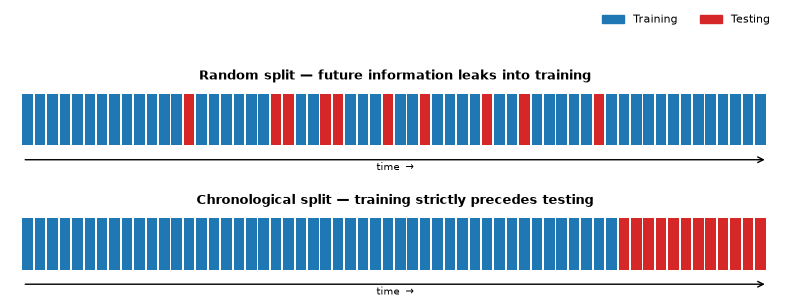

In [93]:
#12

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 3.2))
np.random.seed(1)
n = 60

for ax, title, mode in [(ax1, 'Random split — future information leaks into training', 'rand'),
                        (ax2, 'Chronological split — training strictly precedes testing', 'chrono')]:
    cols = (np.random.choice(['C0','C3'], n, p=[0.8,0.2]) if mode=='rand'
            else ['C0']*48 + ['C3']*12)
    for i, c in enumerate(cols):
        ax.add_patch(Rectangle((i,0), 0.85, 1, facecolor=c))
    ax.set_xlim(-1, n+1); ax.set_ylim(-0.5, 1.6); ax.axis('off')
    ax.text(n/2, 1.28, title, ha='center', fontsize=9, fontweight='bold')
    ax.annotate('', xy=(n,-0.28), xytext=(0,-0.28),
                arrowprops=dict(arrowstyle='->', lw=1))
    ax.text(n/2, -0.48, 'time  →', ha='center', fontsize=7.5)

ax1.legend(handles=[mpatches.Patch(color='C0', label='Training'),
                    mpatches.Patch(color='C3', label='Testing')],
           loc='upper right', frameon=False, fontsize=8, ncol=2,
           bbox_to_anchor=(1.0, 1.55))
plt.tight_layout()
plt.savefig('outputs/fig3_3_split.png', dpi=200, bbox_inches='tight')
plt.show()

In [94]:
#13
categorical_cols = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'DeviceType', 'DeviceInfo', 'addr1', 'addr2']
categorical_cols = [c for c in categorical_cols if c in df.columns]

for c in categorical_cols:
    df[c] = df[c].astype('category') 

In [95]:
#14
drop_cols = ['TransactionID', 'TransactionDT', 'isFraud']
features = [c for c in df.columns if c not in drop_cols]
X_train = train_df[features]
y_train = train_df['isFraud']
X_test = test_df[features]
y_test = test_df['isFraud']

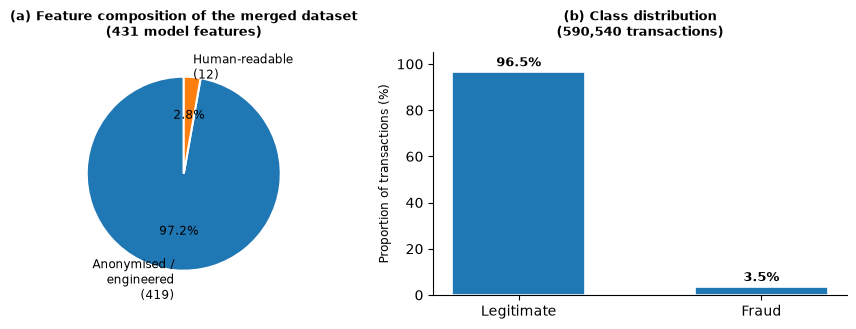

In [96]:
#15

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.4))

n_nameable = len(nameable)
n_anon = len(features) - n_nameable
fraud_pct = 100 * df['isFraud'].mean()

ax1.pie([n_anon, n_nameable],
        labels=[f'Anonymised /\nengineered\n({n_anon})', f'Human-readable\n({n_nameable})'],
        autopct='%1.1f%%', startangle=90, textprops={'fontsize': 8.5},
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax1.set_title(f'(a) Feature composition of the merged dataset\n({len(features)} model features)',
              fontsize=9, fontweight='bold', pad=12)

ax2.bar(['Legitimate', 'Fraud'], [100-fraud_pct, fraud_pct], width=0.55,
        edgecolor='white', linewidth=1.2)
ax2.set_ylabel('Proportion of transactions (%)', fontsize=8.5)
ax2.set_ylim(0, 105)
for i, v in enumerate([100-fraud_pct, fraud_pct]):
    ax2.text(i, v+2.5, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax2.set_title(f'(b) Class distribution\n({len(df):,} transactions)',
              fontsize=9, fontweight='bold', pad=12)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/fig3_2_dataset.png', dpi=200, bbox_inches='tight')
plt.show()

In [97]:
#16
for col in categorical_cols:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

print("X_train shape:", X_train.shape)

print("X_test shape:", X_test.shape)

X_train shape: (472432, 431)
X_test shape: (118108, 431)


In [98]:
#17
X_train.to_pickle('./ieee-fraud-detection/X_train.pkl')
X_test.to_pickle('./ieee-fraud-detection/X_test.pkl')
y_train.to_pickle('./ieee-fraud-detection/y_train.pkl')
y_test.to_pickle('./ieee-fraud-detection/y_test.pkl')

In [99]:
#18
X_train = pd.read_pickle('./ieee-fraud-detection/X_train.pkl')
X_test = pd.read_pickle('./ieee-fraud-detection/X_test.pkl')
y_train = pd.read_pickle('./ieee-fraud-detection/y_train.pkl')
y_test = pd.read_pickle('./ieee-fraud-detection/y_test.pkl')
print("Reloaded Data shapes: ", X_train.shape, X_test.shape, y_train.shape, y_test.shape)

Reloaded Data shapes:  (472432, 431) (118108, 431) (472432,) (118108,)


In [100]:

#19
def get_categorical_cols(X):
    return X.select_dtypes(exclude=[np.number, 'bool']).columns.tolist()

cat_cols = get_categorical_cols(df[features])

# Build shared vocabulary, explicitly handling NaN -> placeholder string
category_maps = {}
for col in cat_cols:
    vals = df[col].astype(object).where(df[col].notna(), 'missing_value').astype(str).unique().tolist()
    category_maps[col] = vals

def cast_with_shared_categories(X, cat_cols, category_maps):
    X = X.copy()
    for col in cat_cols:
        X[col] = X[col].astype(object).where(X[col].notna(), 'missing_value').astype(str)
        X[col] = pd.Categorical(X[col], categories=category_maps[col])
    return X

val_split_idx = int(len(train_df) * 0.85)
train_sub = train_df.iloc[:val_split_idx]
val_sub = train_df.iloc[val_split_idx:]

X_train_sub = cast_with_shared_categories(train_sub[features], cat_cols, category_maps)
y_train_sub = train_sub['isFraud'].copy()
X_val_sub = cast_with_shared_categories(val_sub[features], cat_cols, category_maps)
y_val_sub = val_sub['isFraud'].copy()

X_train = cast_with_shared_categories(train_df[features], cat_cols, category_maps)
y_train = train_df['isFraud'].copy()
X_test = cast_with_shared_categories(test_df[features], cat_cols, category_maps)
y_test = test_df['isFraud'].copy()

print("X_train_sub:", X_train_sub.shape, "| X_val_sub:", X_val_sub.shape)
print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print(X_train_sub.dtypes.value_counts())

X_train_sub: (401567, 431) | X_val_sub: (70865, 431)
X_train: (472432, 431) | X_test: (118108, 431)
float64     397
category     12
category      4
category      1
int64         1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
Name: count, dtype: int64


In [101]:
#20
print(df[features].dtypes.value_counts())

float64     397
str          24
category      1
int64         1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
category      1
Name: count, dtype: int64


## Hyperparameter search
30-trial Optuna study maximising AUPRC on a chronologically held-out validation
partition. Best parameters cached to models/best_params.json.

In [ ]:
#21
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'scale_pos_weight': (len(y_train_sub) - y_train_sub.sum()) / y_train_sub.sum(),
        'eval_metric': 'aucpr',
        'enable_categorical': True,
        'tree_method': 'hist',
        'device': 'cuda',
        'random_state': 42
    }
    model = xgb.XGBClassifier(**params)
    model.fit(X_train_sub, y_train_sub)
    val_proba = model.predict_proba(X_val_sub)[:, 1]
    return average_precision_score(y_val_sub, val_proba)

In [103]:
#22
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

[I 2026-09-06 03:51:24,649] A new study created in memory with name: no-name-8a739302-d67a-4758-8b2e-d04b3ef475f9
[I 2026-09-06 03:51:38,475] Trial 0 finished with value: 0.456119181741964 and parameters: {'n_estimators': 218, 'max_depth': 6, 'learning_rate': 0.01671124558580021, 'subsample': 0.6316011276276835, 'colsample_bytree': 0.6569247723267663, 'min_child_weight': 4}. Best is trial 0 with value: 0.456119181741964.
[I 2026-09-06 03:51:52,173] Trial 1 finished with value: 0.5342539848921158 and parameters: {'n_estimators': 130, 'max_depth': 9, 'learning_rate': 0.06602831288065729, 'subsample': 0.760109774160636, 'colsample_bytree': 0.65042273340884, 'min_child_weight': 10}. Best is trial 1 with value: 0.5342539848921158.
[I 2026-09-06 03:52:18,946] Trial 2 finished with value: 0.5749328519733319 and parameters: {'n_estimators': 491, 'max_depth': 8, 'learning_rate': 0.0884424554091599, 'subsample': 0.8604361183012825, 'colsample_bytree': 0.8108955804184588, 'min_child_weight': 6}. 

In [104]:
#23
print("Best AUPRC (validation):", study.best_value)
print("Best params:", study.best_params)

Best AUPRC (validation): 0.6209095812546788
Best params: {'n_estimators': 394, 'max_depth': 10, 'learning_rate': 0.26631962973650486, 'subsample': 0.9525165340236249, 'colsample_bytree': 0.9798313029766214, 'min_child_weight': 8}


In [105]:
#24
best_params = study.best_params.copy()
best_params['scale_pos_weight'] = (len(y_train) - y_train.sum()) / y_train.sum()
best_params['eval_metric'] = 'aucpr'
best_params['enable_categorical'] = True
best_params['tree_method'] = 'hist'
best_params['device'] = 'cuda'
best_params['random_state'] = 42

final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_train, y_train)



,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9798313029766214
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [110]:
with open('models/best_params.json', 'w') as f:
    json.dump(best_params, f)

In [111]:
#25
with open('models/best_params.json', 'r') as f:
    best_params = json.load(f)

final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_train, y_train)

print("Retrained final_model using saved best_params.")

Retrained final_model using saved best_params.


## Baseline classifier results
Evaluated on the held-out chronological test partition (n = 118,108).
AUPRC 0.534, fraud-class F1 0.528. Reported in Table 5.1.

In [ ]:
#29
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, digits=4))
print("AUPRC:", average_precision_score(y_test, y_proba))
print("F1 (fraud class):", f1_score(y_test, y_pred))

              precision    recall  f1-score   support

           0     0.9832    0.9832    0.9832    114044
           1     0.5277    0.5276    0.5276      4064

    accuracy                         0.9675    118108
   macro avg     0.7554    0.7554    0.7554    118108
weighted avg     0.9675    0.9675    0.9675    118108

AUPRC: 0.5343929843511723
F1 (fraud class): 0.5276239694844346


In [113]:
#30

os.makedirs('models', exist_ok=True)

final_model.save_model('models/xgb_baseline.json')

In [ ]:
#31
with open('models/best_params.json', 'w') as f:
    json.dump(best_params, f, indent=2, default=str)

print("Saved model and params.")

Saved model and params.


## Phase 2: SHAP attribution
TreeExplainer gives exact Shapley values for tree ensembles in polynomial time,
so the full test set is attributed rather than sub-sampled. The 118,108 x 431
matrix is cached to outputs/shap/.

In [ ]:
#32
explainer = shap.TreeExplainer(final_model)

In [116]:
#33
X_test_sample = X_test.sample(n=2000, random_state = 42)
shap_values_sample = explainer.shap_values(X_test_sample)
print(type(shap_values_sample), shap_values_sample.shape if hasattr(shap_values_sample, 'shape') else len(shap_values_sample))

<class 'numpy.ndarray'> (2000, 431)


In [ ]:
#34
sample_size = 10000 # checking with 10k samples for SHAP values to avoid memory issues
X_test_shap, _, y_test_shap, _ = train_test_split(X_test, y_test, train_size = sample_size, stratify = y_test, random_state = 42)

print("X_test_shap shape:", X_test_shap.shape)
print("y_test_shap shape:", y_test_shap.shape)

X_test_shap shape: (10000, 431)
y_test_shap shape: (10000,)


In [ ]:
#35
start = time.time()
shap_values_full = explainer.shap_values(X_test_shap)
elapsed_time = time.time() - start
print(f"Time Taken: {elapsed_time:.1f} seconds")
print(shap_values_full.shape)

Time Taken: 2.2 seconds
(10000, 431)


In [119]:
shap_values_full = np.load('outputs/shap/shap_values_full.npy')

In [120]:
#36
start = time.time()
shap_values_full = explainer.shap_values(X_test)
elapsed_time = time.time() - start
print(f"Time Taken: {elapsed_time:.1f} seconds")
print(shap_values_full.shape)

Time Taken: 24.5 seconds
(118108, 431)


In [31]:
#37
def get_top_features(idx, X, shap_values, k = 5):
    """Return top k features by absolute SHAP values for a given row index"""
    contributions = shap_values[idx]
    top_idx = np.argsort(np.abs(contributions))[-k:][::-1]
    return [(X.columns[i], X.iloc[idx][X.columns[i]], contributions[i]) for i in top_idx]

fraud_indices = np.where(y_test.values == 1)[0]
sample_idx = fraud_indices[0]

top_features = get_top_features(sample_idx, X_test, shap_values_full, k = 5)
for feat_name, feat_val, shap_val in top_features:
    print(f"Feature: {feat_name}, Value: {feat_val}, SHAP value: {shap_val:.4f}")

Feature: id_20, Value: 417.0, SHAP value: 0.7267
Feature: id_31, Value: chrome 65.0, SHAP value: -0.7246
Feature: TransactionAmt, Value: 33.261, SHAP value: -0.6610
Feature: card2, Value: 103.0, SHAP value: -0.5864
Feature: R_emaildomain, Value: gmail.com, SHAP value: 0.4987


In [122]:
#38
os.makedirs('outputs/shap', exist_ok=True)
np.save('outputs/shap/shap_values_full.npy', shap_values_full)
X_test.to_pickle('outputs/shap/X_test_full.pkl')
y_test.to_pickle('outputs/shap/y_test_full.pkl')
np.save('outputs/shap/expected_value.npy', np.array(explainer.expected_value))
print("Saved.")

Saved.


In [ ]:
#39
shap_values_full = np.load('outputs/shap/shap_values_full.npy')
X_test = pd.read_pickle('outputs/shap/X_test_full.pkl')
y_test = pd.read_pickle('outputs/shap/y_test_full.pkl')
expected_value = np.load('outputs/shap/expected_value.npy')

print("Loaded SHAP outputs from disk. shap_values_full shape:", shap_values_full.shape)

Loaded SHAP outputs from disk. shap_values_full shape: (118108, 431)


In [ ]:
#40
for i in fraud_indices[1:5]:
    print(f"\n--- Transaction index {i} ---")
    top_feats = get_top_features(i, X_test, shap_values_full, k=5)
    for feat_name, feat_val, shap_val in top_feats:
        print(f"{feat_name}: value={feat_val}, SHAP={shap_val:.4f}")


--- Transaction index 36 ---
addr1: value=204.0, SHAP=-0.7778
TransactionAmt: value=49.0, SHAP=-0.6518
card2: value=321.0, SHAP=-0.3939
M6: value=T, SHAP=-0.3626
M5: value=F, SHAP=-0.3197

--- Transaction index 67 ---
C6: value=7.0, SHAP=0.8373
C8: value=8.0, SHAP=0.8292
C11: value=6.0, SHAP=0.7720
C10: value=8.0, SHAP=0.5872
V62: value=3.0, SHAP=0.5862

--- Transaction index 72 ---
V258: value=2.0, SHAP=1.3962
addr1: value=missing_value, SHAP=-0.7887
card1: value=16132, SHAP=-0.7714
C13: value=5.0, SHAP=-0.7499
C1: value=5.0, SHAP=0.7448

--- Transaction index 75 ---
C14: value=0.0, SHAP=1.1779
C13: value=0.0, SHAP=0.9003
P_emaildomain: value=hotmail.com, SHAP=-0.7745
card6: value=credit, SHAP=0.6897
id_02: value=196094.0, SHAP=-0.5723


## The interpretability ceiling
Counts how many of each fraud transaction's top-5 SHAP drivers are
human-readable. 19.0% have none, 64.9% have one or two, 16.1% have three or
more. Motivates the tier system in Section 4.3.

In [ ]:
#41
nameable_set = set(nameable)
def count_nameable_in_top_k(idx, X, shap_values, k = 5):
    """Count how many of the top k features by absolute SHAP values are in the nameable set"""
    top_feats = get_top_features(idx, X, shap_values, k=k)
    count = sum(1 for feat_name, _, _ in top_feats if feat_name in nameable_set)
    return count
count = [count_nameable_in_top_k(i, X_test, shap_values_full, k=5) for i in fraud_indices]

counts_series = pd.Series(count)
print(counts_series.value_counts().sort_index())
print("\n Total fraud transactions:", len(counts_series))
print(f"% with 0 nameable features in top 5: {(counts_series == 0).mean() * 100:.1f}%")
print(f"% with 1-2 nameable features in top 5: {(counts_series.isin([1, 2])).mean() * 100:.1f}%")
print(f"% with 3+ nameable features in top 5: {(counts_series >= 3).mean() * 100:.1f}%")

0     771
1    1318
2    1320
3     539
4     110
5       6
Name: count, dtype: int64

 Total fraud transactions: 4064
% with 0 nameable features in top 5: 19.0%
% with 1-2 nameable features in top 5: 64.9%
% with 3+ nameable features in top 5: 16.1%


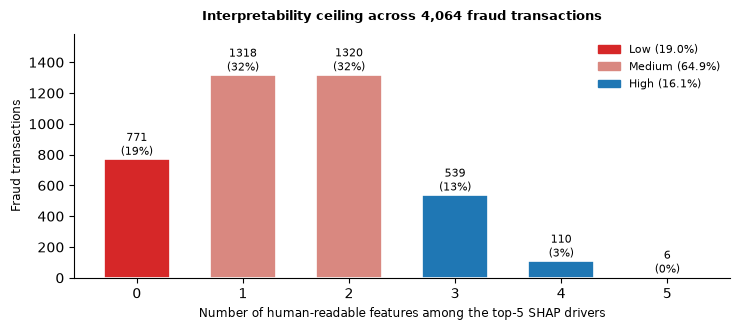

In [ ]:
#42
counts = counts_series.value_counts().sort_index()
total = counts.sum()
colours = ['C3' if i==0 else ('#D98880' if i<=2 else 'C0') for i in counts.index]

fig, ax = plt.subplots(figsize=(7.5, 3.4))
bars = ax.bar(counts.index.astype(str), counts.values, width=0.62,
              color=colours, edgecolor='white', linewidth=1.2)
for b, v in zip(bars, counts.values):
    ax.text(b.get_x()+b.get_width()/2, v+28, f'{v}\n({100*v/total:.0f}%)',
            ha='center', fontsize=8)

low = 100*(counts_series==0).mean()
med = 100*counts_series.isin([1,2]).mean()
high = 100*(counts_series>=3).mean()

ax.set_xlabel('Number of human-readable features among the top-5 SHAP drivers', fontsize=8.5)
ax.set_ylabel('Fraud transactions', fontsize=8.5)
ax.set_ylim(0, counts.max()*1.20)
ax.spines[['top','right']].set_visible(False)
ax.set_title(f'Interpretability ceiling across {total:,} fraud transactions',
             fontsize=9.5, fontweight='bold', pad=10)
ax.legend(handles=[mpatches.Patch(color='C3', label=f'Low ({low:.1f}%)'),
                   mpatches.Patch(color='#D98880', label=f'Medium ({med:.1f}%)'),
                   mpatches.Patch(color='C0', label=f'High ({high:.1f}%)')],
          frameon=False, fontsize=8, loc='upper right')
plt.tight_layout()
plt.savefig('outputs/fig4_2_interpretability.png', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
#43
def interpretability_tier(count):
    if count == 0:
        return "low"       
    elif count <= 2:
        return "medium"    
    else:
        return "high"      

tiers = counts_series.apply(interpretability_tier)
print(tiers.value_counts())


fraud_tier_map = dict(zip(fraud_indices, tiers))

medium    2638
low        771
high       655
Name: count, dtype: int64


In [ ]:
#44
with open('outputs/shap/fraud_tier_map.pkl', 'wb') as f:
    pickle.dump(fraud_tier_map, f)
print("Saved tier mapping.")

Saved tier mapping.


## Phase 3: Serialisation
Features are described three ways: named for human-readable columns,
"internal identifier" for card1-card5, and generic for engineered blocks.
Missing values are stated explicitly rather than rendered as evidence.

In [ ]:
#45
def describe_feature(feat_name, feat_val):
    """Turn a raw feature name+value into a human readable phrase."""
    if feat_val in ('missing_value', 'nan') or pd.isna(feat_val):
        return f"a missing/undisclosed value for feature {feat_name}"
    if feat_name == 'TransactionAmt':
        try:
            return f"a transaction amount of ${float(feat_val):.2f}"
        except (ValueError, TypeError):
            return f"a transaction amount of {feat_val}"
    elif feat_name == 'ProductCD':
        return f"product category '{feat_val}'"
    elif feat_name == 'card4':
        return f"a {feat_val} card"
    elif feat_name == 'card6':
        return f"a {feat_val} card type"
    elif feat_name in ('card1', 'card2', 'card3', 'card5'):
        return f"an internal card identifier ({feat_name}) with value {feat_val}"
    elif feat_name == 'P_emaildomain':
        return f"purchaser email domain '{feat_val}'"
    elif feat_name == 'R_emaildomain':
        return f"recipient email domain '{feat_val}'"
    elif feat_name == 'DeviceType':
        return f"device type '{feat_val}'"
    elif feat_name == 'DeviceInfo':
        return f"device info '{feat_val}'"
    elif feat_name == 'addr1':
        return f"billing region code {feat_val}"
    elif feat_name == 'addr2':
        return f"billing country code {feat_val}"
    elif feat_name == 'dist1':
        return f"a distance metric of {feat_val}"
    elif feat_name == 'dist2':
        return f"a secondary distance metric of {feat_val}"
    elif feat_name.startswith('id_') and any(b in str(feat_val).lower() for b in ['chrome', 'firefox', 'safari', 'edge']):
        return f"browser/user-agent info '{feat_val}'"
    else:
        return f"an engineered risk indicator ({feat_name}) with value {feat_val}"


test_feats = get_top_features(fraud_indices[0], X_test, shap_values_full, k=5)
for feat_name, feat_val, shap_val in test_feats:
    direction = "increasing" if shap_val > 0 else "decreasing"
    print(f"- {describe_feature(feat_name, feat_val)} ({direction} fraud likelihood)")

- an engineered risk indicator (id_20) with value 417.0 (increasing fraud likelihood)
- browser/user-agent info 'chrome 65.0' (decreasing fraud likelihood)
- a transaction amount of $33.26 (decreasing fraud likelihood)
- an internal card identifier (card2) with value 103.0 (decreasing fraud likelihood)
- recipient email domain 'gmail.com' (increasing fraud likelihood)


In [ ]:
#46
def generate_explanation(idx, X, shap_values, k=5):
    top_feats = get_top_features(idx, X, shap_values, k=k)
    
    fraud_indicators = []
    legit_indicators = []
    
    for feat_name, feat_val, shap_val in top_feats:
        desc = describe_feature(feat_name, feat_val)
        if shap_val > 0:
            fraud_indicators.append(desc)
        else:
            legit_indicators.append(desc)
    
    parts = []
    if fraud_indicators:
        parts.append(f"Factors increasing fraud risk: {'; '.join(fraud_indicators)}.")
    if legit_indicators:
        parts.append(f"Factors decreasing fraud risk: {'; '.join(legit_indicators)}.")
    
    return " ".join(parts)


explanation = generate_explanation(fraud_indices[0], X_test, shap_values_full, k=5)
print(explanation)

Factors increasing fraud risk: an engineered risk indicator (id_20) with value 417.0; recipient email domain 'gmail.com'. Factors decreasing fraud risk: browser/user-agent info 'chrome 65.0'; a transaction amount of $33.26; an internal card identifier (card2) with value 103.0.


In [ ]:
#47
def generate_full_explanation_record(idx, X, y, shap_values, nameable_set, k=5):
    top_feats = get_top_features(idx, X, shap_values, k=k)
    nameable_count = sum(1 for feat_name, _, _ in top_feats if feat_name in nameable_set)
    tier = interpretability_tier(nameable_count)
    
    explanation_text = generate_explanation(idx, X, shap_values, k=k)
    true_label = "Fraud" if y.iloc[idx] == 1 else "Legitimate"
    
    return {
        'index': idx,
        'true_label': true_label,
        'explanation': explanation_text,
        'interpretability_tier': tier,
        'nameable_count': nameable_count
    }

record = generate_full_explanation_record(fraud_indices[0], X_test, y_test, shap_values_full, nameable_set, k=5)
for key, val in record.items():
    print(f"{key}: {val}")

index: 0
true_label: Fraud
explanation: Factors increasing fraud risk: an engineered risk indicator (id_20) with value 417.0; recipient email domain 'gmail.com'. Factors decreasing fraud risk: browser/user-agent info 'chrome 65.0'; a transaction amount of $33.26; an internal card identifier (card2) with value 103.0.
interpretability_tier: medium
nameable_count: 2


In [ ]:
#48
def serialize_transaction(idx, X, nameable_set):
    row = X.iloc[idx]
    
    parts = []
    for feat_name in nameable_set:
        if feat_name in X.columns:
            val = row[feat_name]
            if pd.notna(val) and str(val) not in ('nan', 'missing_value'):
                parts.append(describe_feature(feat_name, val))
    
    return "Transaction details: " + "; ".join(parts) + "."

sample_prompt = serialize_transaction(fraud_indices[0], X_test, nameable_set)
print(sample_prompt)

Transaction details: purchaser email domain 'gmail.com'; recipient email domain 'gmail.com'; a debit card type; device type 'desktop'; a transaction amount of $33.26; product category 'C'; a visa card.


In [ ]:
#49
def build_training_example(idx, X, y, shap_values, nameable_set, k=5):
    prompt = serialize_transaction_with_attributions(idx, X, y, shap_values, nameable_set, k=k)
    record = generate_full_explanation_record(idx, X, y, shap_values, nameable_set, k=k)
    return {
        'prompt': prompt,
        'true_label': record['true_label'],
        'target_explanation': record['explanation'],
        'interpretability_tier': record['interpretability_tier']
    }

example = build_training_example(fraud_indices[0], X_test, y_test, shap_values_full, nameable_set)
for key, val in example.items():
    print(f"{key}: {val}\n")

prompt: Transaction details: purchaser email domain 'gmail.com'; recipient email domain 'gmail.com'; a debit card type; device type 'desktop'; a transaction amount of $33.26; product category 'C'; a visa card. Model-identified risk factors: id_20 (value: 417.0) increases fraud risk; id_31 (value: chrome 65.0) decreases fraud risk; TransactionAmt (value: 33.261) decreases fraud risk; card2 (value: 103.0) decreases fraud risk; R_emaildomain (value: gmail.com) increases fraud risk.

true_label: Fraud

target_explanation: Factors increasing fraud risk: an engineered risk indicator (id_20) with value 417.0; recipient email domain 'gmail.com'. Factors decreasing fraud risk: browser/user-agent info 'chrome 65.0'; a transaction amount of $33.26; an internal card identifier (card2) with value 103.0.

interpretability_tier: medium



In [ ]:
#50
def serialize_transaction_with_attributions(idx, X, y, shap_values, nameable_set, k=5):
    base_prompt = serialize_transaction(idx, X, nameable_set)
    top_feats = get_top_features(idx, X, shap_values, k=k)
    
    attribution_lines = []
    for feat_name, feat_val, shap_val in top_feats:
        direction = "increases" if shap_val > 0 else "decreases"
        if feat_val in ('missing_value', 'nan') or pd.isna(feat_val):
            display_val = "missing/undisclosed"
        else:
            display_val = feat_val
        attribution_lines.append(f"{feat_name} (value: {display_val}) {direction} fraud risk")
    
    attributions_text = "Model-identified risk factors: " + "; ".join(attribution_lines) + "."
    return base_prompt + " " + attributions_text

example = build_training_example(fraud_indices[0], X_test, y_test, shap_values_full, nameable_set)
for key, val in example.items():
    print(f"{key}: {val}\n")

prompt: Transaction details: purchaser email domain 'gmail.com'; recipient email domain 'gmail.com'; a debit card type; device type 'desktop'; a transaction amount of $33.26; product category 'C'; a visa card. Model-identified risk factors: id_20 (value: 417.0) increases fraud risk; id_31 (value: chrome 65.0) decreases fraud risk; TransactionAmt (value: 33.261) decreases fraud risk; card2 (value: 103.0) decreases fraud risk; R_emaildomain (value: gmail.com) increases fraud risk.

true_label: Fraud

target_explanation: Factors increasing fraud risk: an engineered risk indicator (id_20) with value 417.0; recipient email domain 'gmail.com'. Factors decreasing fraud risk: browser/user-agent info 'chrome 65.0'; a transaction amount of $33.26; an internal card identifier (card2) with value 103.0.

interpretability_tier: medium



Balanced corpus of 8,128 examples, equal fraud and legitimate. Balanced for
explanation coverage, not for class imbalance: at natural 3.5% prevalence the
corpus would hold only ~300 fraud explanations.

In [ ]:
#51
random.seed(42)
legit_indices = np.where(y_test.values == 0)[0]
legit_idx_sample = random.sample(list(legit_indices), len(fraud_indices))
all_indices = list(fraud_indices) + legit_idx_sample
random.shuffle(all_indices)

In [ ]:
#52
import time
training_data = []
start = time.time()
for i, idx in enumerate(all_indices):
    ex = build_training_example(idx, X_test, y_test, shap_values_full, nameable_set)
    ex['index'] = int(idx)
    training_data.append(ex)
    if (i+1) % 1000 == 0:
        print(f"Processed {i+1}/{len(all_indices)}. Time elapsed: {time.time()-start:.1f}s")

print(f"Done. Total: {len(training_data)}. Time: {time.time()-start:.1f}s")

Processed 1000/8128. Time elapsed: 11.1s
Processed 2000/8128. Time elapsed: 22.2s
Processed 3000/8128. Time elapsed: 32.8s
Processed 4000/8128. Time elapsed: 43.4s
Processed 5000/8128. Time elapsed: 54.1s
Processed 6000/8128. Time elapsed: 64.5s
Processed 7000/8128. Time elapsed: 75.2s
Processed 8000/8128. Time elapsed: 85.9s
Done. Total: 8128. Time: 87.3s


In [ ]:
#53
with open('ieee-fraud-detection/llm_training_data.json', 'w') as f:
    json.dump(training_data, f, indent = 2)
print("Saved training data to 'ieee-fraud-detection/llm_training_data.json'.")
leak_count = sum(1 for ex in training_data if 'missing_value' in ex['target_explanation'] or 'missing_value' in ex['prompt'])
print(f"Remaining 'missing_value' leaks: {leak_count}")
print("Saved corrected training data.")



Saved training data to 'ieee-fraud-detection/llm_training_data.json'.
Remaining 'missing_value' leaks: 0
Saved corrected training data.


In [ ]:
#54
with open('ieee-fraud-detection/llm_training_data.json') as f:
    training_data = json.load(f)
print(f"training_data: {len(training_data)} examples")

training_data: 8128 examples


In [53]:
#55
labels = [ex['true_label'] for ex in training_data]
tiers = [ex['interpretability_tier'] for ex in training_data]
print(pd.Series(labels).value_counts())
print(pd.Series(tiers).value_counts())

Legitimate    4064
Fraud         4064
Name: count, dtype: int64
medium    5373
high      1992
low        763
Name: count, dtype: int64


In [137]:
#56
random.seed(1)
sample_check = random.sample(training_data, 4)

for ex in sample_check:
    print(f"[{ex['true_label']} | {ex['interpretability_tier']}]")
    print(f"Prompt: {ex['prompt']}")
    print(f"Explanation : {ex['target_explanation']}\n")

[Fraud | medium]
Prompt: Transaction details: billing region code 325.0; a visa card; a debit card type; product category 'W'; a transaction amount of $87.00; billing country code 87.0; purchaser email domain 'gmail.com'; a distance metric of 753.0. Model-identified risk factors: addr1 (value: 325.0) decreases fraud risk; D2 (value: 1.0) increases fraud risk; card1 (value: 8394) decreases fraud risk; TransactionAmt (value: 87.0) decreases fraud risk; M6 (value: missing/undisclosed) decreases fraud risk.
Explanation : Factors increasing fraud risk: an engineered risk indicator (D2) with value 1.0. Factors decreasing fraud risk: billing region code 325.0; an internal card identifier (card1) with value 8394; a transaction amount of $87.00; a missing/undisclosed value for feature M6.

[Legitimate | medium]
Prompt: Transaction details: billing region code 324.0; a visa card; a debit card type; product category 'W'; a transaction amount of $34.00; billing country code 87.0; purchaser email d

In [138]:
#57
def format_for_mistral(example):
     instruction = (
        "You are a fraud detection assistant. Given the transaction details below, "
        "classify the transaction as Fraud or Legitimate, and explain your reasoning "
        "based on the key risk factors."
    )
     user_content = f"{instruction} \n\n{example['prompt']}"
     assistant_content = f"Classification: {example['true_label']}\n{example['target_explanation']}"

     return {
          "text": f"<s>[INST] {user_content} [/INST] {assistant_content}</s>"
     }

formatted_data = [format_for_mistral(ex) for ex in training_data]
print(formatted_data[0]['text'])

<s>[INST] You are a fraud detection assistant. Given the transaction details below, classify the transaction as Fraud or Legitimate, and explain your reasoning based on the key risk factors. 

Transaction details: billing region code 272.0; a visa card; a debit card type; product category 'W'; a transaction amount of $49.00; billing country code 87.0. Model-identified risk factors: C13 (value: 21.0) decreases fraud risk; addr1 (value: 272.0) decreases fraud risk; D15 (value: 90.0) decreases fraud risk; V294 (value: 2.0) increases fraud risk; card1 (value: 4436) decreases fraud risk. [/INST] Classification: Legitimate
Factors increasing fraud risk: an engineered risk indicator (V294) with value 2.0. Factors decreasing fraud risk: an engineered risk indicator (C13) with value 21.0; billing region code 272.0; an engineered risk indicator (D15) with value 90.0; an internal card identifier (card1) with value 4436.</s>


In [ ]:
#58

train_formatted, val_formatted = train_test_split(formatted_data, test_size = 0.1, random_state = 42)
print(f"Fine-tuning train size: {len(train_formatted)}")
print(f"Fine-tuning val size: {len(val_formatted)}")

Fine-tuning train size: 7315
Fine-tuning val size: 813


In [140]:
#59
import json

with open('ieee-fraud-detection/llm_train_formatted.json', 'w') as f:
    json.dump(train_formatted, f, indent=2)

with open('ieee-fraud-detection/llm_val_formatted.json', 'w') as f:
    json.dump(val_formatted, f, indent=2)

print("Saved formatted train/val sets.")

Saved formatted train/val sets.


## Phase 4: QLoRA fine-tuning
Mistral-7B-Instruct-v0.2 in 4-bit NF4, rank-32 adapters on all four attention
and three feed-forward projections (83.9M trainable, 1.15%).

In [ ]:
#60
model_name = "mistralai/Mistral-7B-Instruct-v0.2"

In [ ]:
#61
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True
)
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(model_name, quantization_config=bnb_config, device_map="auto")
print("Loaded model and tokenizer.")
print(f"Memory footprint (GB): {model.get_memory_footprint() / 1e9:.2f}")

W0906 23:15:08.003000 25068 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

  torch._check_is_size(blocksize)


Loaded model and tokenizer.
Memory footprint (GB): 4.01


In [ ]:
#62
with open('ieee-fraud-detection/llm_train_formatted.json', 'r') as f:
    train_formatted = json.load(f)
with open('ieee-fraud-detection/llm_val_formatted.json', 'r') as f:
    val_formatted = json.load(f)

print(len(train_formatted), len(val_formatted))

7315 813


In [ ]:
#63
model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=32,
    lora_alpha=64,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()
print("Model type after LoRA:", type(model))

trainable params: 83,886,080 || all params: 7,325,618,176 || trainable%: 1.1451
Model type after LoRA: <class 'peft.peft_model.PeftModelForCausalLM'>


In [ ]:
#64
train_dataset = Dataset.from_list(train_formatted)
val_dataset = Dataset.from_list(val_formatted)

MAX_LEN = 320

def tokenize_function(examples):
    tokenized = tokenizer(
        examples["text"], truncation=True, max_length=MAX_LEN,
        padding="max_length", add_special_tokens=False
    )
    labels = []
    for i, ids in enumerate(tokenized["input_ids"]):
        text = examples["text"][i]
        unpadded_ids = tokenizer(text, truncation=True, max_length=MAX_LEN, add_special_tokens=False)["input_ids"]
        real_len = len(unpadded_ids)

        prompt_part = text.split("[/INST]")[0] + "[/INST]"
        prompt_token_len = len(tokenizer(prompt_part, add_special_tokens=False)["input_ids"])

        label = list(ids)
        for j in range(len(label)):
            if j < prompt_token_len or j >= real_len:
                label[j] = -100
        labels.append(label)
    tokenized["labels"] = labels
    return tokenized

train_tokenized = train_dataset.map(tokenize_function, batched=True, remove_columns=["text"])
val_tokenized = val_dataset.map(tokenize_function, batched=True, remove_columns=["text"])
print("Re-tokenized with EOS fix.", train_tokenized)

Map:   0%|          | 0/7315 [00:00<?, ? examples/s]

Map:   0%|          | 0/813 [00:00<?, ? examples/s]

Re-tokenized with EOS fix. Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 7315
})


In [ ]:
#65
training_args = TrainingArguments(
    output_dir="./models/mistral_fraud_lora",
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,
    num_train_epochs=3,
    learning_rate=2e-4,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=50,
    save_total_limit=2,
    bf16=True,
    gradient_checkpointing=True,
    optim="paged_adamw_8bit",
    report_to="none",
    warmup_ratio=0.03,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False),
)
print("Trainer configured.")

Trainer configured.


1,371 steps over three epochs, approximately 8 hours on an RTX 5060 laptop GPU
with 8.5 GB VRAM.

In [ ]:
#66
tiny_train = train_tokenized.select(range(20))
tiny_val = val_tokenized.select(range(10))

trainer_test = Trainer(
    model=model,
    args=TrainingArguments(
        output_dir="./models/test_run",
        per_device_train_batch_size=2,
        gradient_accumulation_steps=2,
        num_train_epochs=1,
        logging_steps=1,
        bf16=True,
        gradient_checkpointing=True,
        optim="paged_adamw_8bit",
        report_to="none",
    ),
    train_dataset=tiny_train,
    eval_dataset=tiny_val,
    data_collator=DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False),
)

trainer_test.train()

  0%|          | 0/5 [00:00<?, ?it/s]

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


{'loss': 2.6407, 'grad_norm': 22.594406127929688, 'learning_rate': 4e-05, 'epoch': 0.2}
{'loss': 2.0386, 'grad_norm': 12.560487747192383, 'learning_rate': 3e-05, 'epoch': 0.4}
{'loss': 1.686, 'grad_norm': 11.559301376342773, 'learning_rate': 2e-05, 'epoch': 0.6}
{'loss': 1.4828, 'grad_norm': 10.52406120300293, 'learning_rate': 1e-05, 'epoch': 0.8}
{'loss': 1.28, 'grad_norm': 10.17182445526123, 'learning_rate': 0.0, 'epoch': 1.0}
{'train_runtime': 23.7969, 'train_samples_per_second': 0.84, 'train_steps_per_second': 0.21, 'train_loss': 1.8256093502044677, 'epoch': 1.0}


TrainOutput(global_step=5, training_loss=1.8256093502044677, metrics={'train_runtime': 23.7969, 'train_samples_per_second': 0.84, 'train_steps_per_second': 0.21, 'total_flos': 276270573158400.0, 'train_loss': 1.8256093502044677, 'epoch': 1.0})

In [ ]:
#67
print(f"Allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
print(f"Reserved: {torch.cuda.memory_reserved() / 1e9:.2f} GB")
print(f"Max allocated during run: {torch.cuda.max_memory_allocated() / 1e9:.2f} GB")

Allocated: 4.99 GB
Reserved: 5.35 GB
Max allocated during run: 4.99 GB


In [ ]:
#68
trainer.train()

  0%|          | 0/1371 [00:00<?, ?it/s]

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


{'loss': 2.018, 'grad_norm': 30.42588996887207, 'learning_rate': 4.761904761904762e-05, 'epoch': 0.02}
{'loss': 0.4364, 'grad_norm': 8.51040267944336, 'learning_rate': 9.523809523809524e-05, 'epoch': 0.04}
{'loss': 0.2802, 'grad_norm': 6.701913833618164, 'learning_rate': 0.00014285714285714287, 'epoch': 0.07}
{'loss': 0.2152, 'grad_norm': 4.820687294006348, 'learning_rate': 0.00019047619047619048, 'epoch': 0.09}
{'loss': 0.2017, 'grad_norm': 4.062967300415039, 'learning_rate': 0.00019879608728367193, 'epoch': 0.11}


  0%|          | 0/407 [00:00<?, ?it/s]

{'eval_loss': 0.19756311178207397, 'eval_runtime': 255.0806, 'eval_samples_per_second': 3.187, 'eval_steps_per_second': 1.596, 'epoch': 0.11}
{'loss': 0.1936, 'grad_norm': 4.6479268074035645, 'learning_rate': 0.00019729119638826185, 'epoch': 0.13}
{'loss': 0.1864, 'grad_norm': 2.8359570503234863, 'learning_rate': 0.00019578630549285179, 'epoch': 0.15}
{'loss': 0.1783, 'grad_norm': 2.5182924270629883, 'learning_rate': 0.0001942814145974417, 'epoch': 0.17}
{'loss': 0.1727, 'grad_norm': 2.575900077819824, 'learning_rate': 0.0001927765237020316, 'epoch': 0.2}
{'loss': 0.1796, 'grad_norm': 5.583928108215332, 'learning_rate': 0.00019127163280662152, 'epoch': 0.22}


  0%|          | 0/407 [00:00<?, ?it/s]

{'eval_loss': 0.17714717984199524, 'eval_runtime': 255.3239, 'eval_samples_per_second': 3.184, 'eval_steps_per_second': 1.594, 'epoch': 0.22}
{'loss': 0.182, 'grad_norm': 13.587289810180664, 'learning_rate': 0.00018976674191121143, 'epoch': 0.24}
{'loss': 0.1765, 'grad_norm': 2.208899736404419, 'learning_rate': 0.00018826185101580137, 'epoch': 0.26}
{'loss': 0.1744, 'grad_norm': 2.152209520339966, 'learning_rate': 0.00018675696012039128, 'epoch': 0.28}
{'loss': 0.1717, 'grad_norm': 2.5577754974365234, 'learning_rate': 0.0001852520692249812, 'epoch': 0.31}
{'loss': 0.1711, 'grad_norm': 2.0496938228607178, 'learning_rate': 0.0001837471783295711, 'epoch': 0.33}


  0%|          | 0/407 [00:00<?, ?it/s]

{'eval_loss': 0.1669728308916092, 'eval_runtime': 256.7961, 'eval_samples_per_second': 3.166, 'eval_steps_per_second': 1.585, 'epoch': 0.33}
{'loss': 0.1647, 'grad_norm': 1.7693039178848267, 'learning_rate': 0.00018224228743416102, 'epoch': 0.35}
{'loss': 0.1691, 'grad_norm': 1.5370314121246338, 'learning_rate': 0.00018073739653875096, 'epoch': 0.37}
{'loss': 0.167, 'grad_norm': 2.076850414276123, 'learning_rate': 0.00017923250564334087, 'epoch': 0.39}
{'loss': 0.1669, 'grad_norm': 1.4655941724777222, 'learning_rate': 0.00017772761474793078, 'epoch': 0.42}
{'loss': 0.1601, 'grad_norm': 3.642393112182617, 'learning_rate': 0.0001762227238525207, 'epoch': 0.44}


  0%|          | 0/407 [00:00<?, ?it/s]

{'eval_loss': 0.16106145083904266, 'eval_runtime': 255.2617, 'eval_samples_per_second': 3.185, 'eval_steps_per_second': 1.594, 'epoch': 0.44}
{'loss': 0.1593, 'grad_norm': 6.282858371734619, 'learning_rate': 0.0001747178329571106, 'epoch': 0.46}
{'loss': 0.161, 'grad_norm': 2.0597856044769287, 'learning_rate': 0.00017321294206170052, 'epoch': 0.48}
{'loss': 0.1653, 'grad_norm': 1.9002736806869507, 'learning_rate': 0.00017170805116629046, 'epoch': 0.5}
{'loss': 0.1594, 'grad_norm': 1.2451857328414917, 'learning_rate': 0.00017020316027088037, 'epoch': 0.52}
{'loss': 0.1601, 'grad_norm': 2.7049033641815186, 'learning_rate': 0.00016869826937547028, 'epoch': 0.55}


  0%|          | 0/407 [00:00<?, ?it/s]

{'eval_loss': 0.15872691571712494, 'eval_runtime': 255.3149, 'eval_samples_per_second': 3.184, 'eval_steps_per_second': 1.594, 'epoch': 0.55}
{'loss': 0.1541, 'grad_norm': 1.1576817035675049, 'learning_rate': 0.0001671933784800602, 'epoch': 0.57}
{'loss': 0.1584, 'grad_norm': 1.827839732170105, 'learning_rate': 0.0001656884875846501, 'epoch': 0.59}
{'loss': 0.1566, 'grad_norm': 2.444167137145996, 'learning_rate': 0.00016418359668924005, 'epoch': 0.61}
{'loss': 0.1716, 'grad_norm': 2.250556230545044, 'learning_rate': 0.00016267870579382996, 'epoch': 0.63}
{'loss': 0.1549, 'grad_norm': 1.3715598583221436, 'learning_rate': 0.00016117381489841987, 'epoch': 0.66}


  0%|          | 0/407 [00:00<?, ?it/s]

{'eval_loss': 0.15602321922779083, 'eval_runtime': 255.264, 'eval_samples_per_second': 3.185, 'eval_steps_per_second': 1.594, 'epoch': 0.66}
{'loss': 0.1672, 'grad_norm': 4.883276462554932, 'learning_rate': 0.00015966892400300978, 'epoch': 0.68}
{'loss': 0.1628, 'grad_norm': 11.242945671081543, 'learning_rate': 0.0001581640331075997, 'epoch': 0.7}
{'loss': 0.1586, 'grad_norm': 2.4957964420318604, 'learning_rate': 0.00015665914221218963, 'epoch': 0.72}
{'loss': 0.162, 'grad_norm': 1.4514540433883667, 'learning_rate': 0.00015515425131677955, 'epoch': 0.74}
{'loss': 0.1514, 'grad_norm': 1.2953966856002808, 'learning_rate': 0.00015364936042136946, 'epoch': 0.77}


  0%|          | 0/407 [00:00<?, ?it/s]

{'eval_loss': 0.15328867733478546, 'eval_runtime': 255.3197, 'eval_samples_per_second': 3.184, 'eval_steps_per_second': 1.594, 'epoch': 0.77}
{'loss': 0.1589, 'grad_norm': 1.687758445739746, 'learning_rate': 0.00015214446952595937, 'epoch': 0.79}
{'loss': 0.1518, 'grad_norm': 1.3458528518676758, 'learning_rate': 0.00015063957863054928, 'epoch': 0.81}
{'loss': 0.1525, 'grad_norm': 1.2041438817977905, 'learning_rate': 0.00014913468773513922, 'epoch': 0.83}
{'loss': 0.1553, 'grad_norm': 3.39473557472229, 'learning_rate': 0.00014762979683972913, 'epoch': 0.85}
{'loss': 0.1496, 'grad_norm': 1.3532156944274902, 'learning_rate': 0.00014612490594431905, 'epoch': 0.87}


  0%|          | 0/407 [00:00<?, ?it/s]

{'eval_loss': 0.1508525013923645, 'eval_runtime': 255.3423, 'eval_samples_per_second': 3.184, 'eval_steps_per_second': 1.594, 'epoch': 0.87}
{'loss': 0.1561, 'grad_norm': 3.274352550506592, 'learning_rate': 0.00014462001504890896, 'epoch': 0.9}
{'loss': 0.1478, 'grad_norm': 2.520761489868164, 'learning_rate': 0.00014311512415349887, 'epoch': 0.92}
{'loss': 0.1498, 'grad_norm': 1.1175305843353271, 'learning_rate': 0.0001416102332580888, 'epoch': 0.94}
{'loss': 0.1545, 'grad_norm': 1.3632733821868896, 'learning_rate': 0.00014010534236267872, 'epoch': 0.96}
{'loss': 0.1495, 'grad_norm': 1.1653717756271362, 'learning_rate': 0.00013860045146726863, 'epoch': 0.98}


  0%|          | 0/407 [00:00<?, ?it/s]

{'eval_loss': 0.14852888882160187, 'eval_runtime': 255.394, 'eval_samples_per_second': 3.183, 'eval_steps_per_second': 1.594, 'epoch': 0.98}
{'loss': 0.1458, 'grad_norm': 1.4150431156158447, 'learning_rate': 0.00013709556057185855, 'epoch': 1.01}
{'loss': 0.1392, 'grad_norm': 1.5838327407836914, 'learning_rate': 0.00013559066967644846, 'epoch': 1.03}
{'loss': 0.1463, 'grad_norm': 2.655930519104004, 'learning_rate': 0.0001340857787810384, 'epoch': 1.05}
{'loss': 0.1411, 'grad_norm': 0.9749064445495605, 'learning_rate': 0.0001325808878856283, 'epoch': 1.07}
{'loss': 0.1405, 'grad_norm': 1.3266102075576782, 'learning_rate': 0.00013107599699021822, 'epoch': 1.09}


  0%|          | 0/407 [00:00<?, ?it/s]

{'eval_loss': 0.14785011112689972, 'eval_runtime': 255.3568, 'eval_samples_per_second': 3.184, 'eval_steps_per_second': 1.594, 'epoch': 1.09}
{'loss': 0.1474, 'grad_norm': 1.3004332780838013, 'learning_rate': 0.00012957110609480813, 'epoch': 1.12}
{'loss': 0.1374, 'grad_norm': 1.9187581539154053, 'learning_rate': 0.00012806621519939805, 'epoch': 1.14}
{'loss': 0.1428, 'grad_norm': 1.1730602979660034, 'learning_rate': 0.00012656132430398798, 'epoch': 1.16}
{'loss': 0.1437, 'grad_norm': 1.5892982482910156, 'learning_rate': 0.0001250564334085779, 'epoch': 1.18}
{'loss': 0.1457, 'grad_norm': 1.4766114950180054, 'learning_rate': 0.0001235515425131678, 'epoch': 1.2}


  0%|          | 0/407 [00:00<?, ?it/s]

{'eval_loss': 0.1446438431739807, 'eval_runtime': 255.3591, 'eval_samples_per_second': 3.184, 'eval_steps_per_second': 1.594, 'epoch': 1.2}
{'loss': 0.1427, 'grad_norm': 1.4145680665969849, 'learning_rate': 0.00012204665161775772, 'epoch': 1.22}
{'loss': 0.1373, 'grad_norm': 1.2516047954559326, 'learning_rate': 0.00012054176072234765, 'epoch': 1.25}
{'loss': 0.1476, 'grad_norm': 1.0952204465866089, 'learning_rate': 0.00011903686982693756, 'epoch': 1.27}
{'loss': 0.1463, 'grad_norm': 1.3279346227645874, 'learning_rate': 0.00011753197893152747, 'epoch': 1.29}
{'loss': 0.1391, 'grad_norm': 1.159263253211975, 'learning_rate': 0.0001160270880361174, 'epoch': 1.31}


  0%|          | 0/407 [00:00<?, ?it/s]

{'eval_loss': 0.1423017978668213, 'eval_runtime': 255.3025, 'eval_samples_per_second': 3.184, 'eval_steps_per_second': 1.594, 'epoch': 1.31}
{'loss': 0.1408, 'grad_norm': 1.489414095878601, 'learning_rate': 0.00011452219714070731, 'epoch': 1.33}
{'loss': 0.1387, 'grad_norm': 1.5336881875991821, 'learning_rate': 0.00011301730624529723, 'epoch': 1.36}
{'loss': 0.1401, 'grad_norm': 1.6924254894256592, 'learning_rate': 0.00011151241534988715, 'epoch': 1.38}
{'loss': 0.1366, 'grad_norm': 1.2519807815551758, 'learning_rate': 0.00011000752445447706, 'epoch': 1.4}
{'loss': 0.1392, 'grad_norm': 2.8919684886932373, 'learning_rate': 0.00010850263355906698, 'epoch': 1.42}


  0%|          | 0/407 [00:00<?, ?it/s]

{'eval_loss': 0.1405058056116104, 'eval_runtime': 255.3865, 'eval_samples_per_second': 3.183, 'eval_steps_per_second': 1.594, 'epoch': 1.42}
{'loss': 0.1393, 'grad_norm': 1.3260494470596313, 'learning_rate': 0.0001069977426636569, 'epoch': 1.44}
{'loss': 0.1384, 'grad_norm': 1.2268691062927246, 'learning_rate': 0.00010549285176824681, 'epoch': 1.47}
{'loss': 0.1321, 'grad_norm': 1.2747001647949219, 'learning_rate': 0.00010398796087283673, 'epoch': 1.49}
{'loss': 0.1362, 'grad_norm': 1.1635206937789917, 'learning_rate': 0.00010248306997742665, 'epoch': 1.51}
{'loss': 0.1368, 'grad_norm': 1.4896594285964966, 'learning_rate': 0.00010097817908201657, 'epoch': 1.53}


  0%|          | 0/407 [00:00<?, ?it/s]

{'eval_loss': 0.13833902776241302, 'eval_runtime': 255.3856, 'eval_samples_per_second': 3.183, 'eval_steps_per_second': 1.594, 'epoch': 1.53}
{'loss': 0.1417, 'grad_norm': 1.2928990125656128, 'learning_rate': 9.947328818660647e-05, 'epoch': 1.55}
{'loss': 0.1387, 'grad_norm': 1.2200534343719482, 'learning_rate': 9.79683972911964e-05, 'epoch': 1.57}
{'loss': 0.1348, 'grad_norm': 1.3996789455413818, 'learning_rate': 9.646350639578631e-05, 'epoch': 1.6}
{'loss': 0.1331, 'grad_norm': 1.4489514827728271, 'learning_rate': 9.495861550037622e-05, 'epoch': 1.62}
{'loss': 0.1335, 'grad_norm': 1.2207554578781128, 'learning_rate': 9.345372460496615e-05, 'epoch': 1.64}


  0%|          | 0/407 [00:00<?, ?it/s]

{'eval_loss': 0.13542518019676208, 'eval_runtime': 255.3813, 'eval_samples_per_second': 3.183, 'eval_steps_per_second': 1.594, 'epoch': 1.64}
{'loss': 0.1311, 'grad_norm': 1.5571409463882446, 'learning_rate': 9.194883370955606e-05, 'epoch': 1.66}
{'loss': 0.1335, 'grad_norm': 1.1663726568222046, 'learning_rate': 9.044394281414598e-05, 'epoch': 1.68}
{'loss': 0.1308, 'grad_norm': 1.037712574005127, 'learning_rate': 8.89390519187359e-05, 'epoch': 1.71}
{'loss': 0.1335, 'grad_norm': 1.3123252391815186, 'learning_rate': 8.743416102332581e-05, 'epoch': 1.73}
{'loss': 0.1279, 'grad_norm': 1.3822441101074219, 'learning_rate': 8.592927012791573e-05, 'epoch': 1.75}


  0%|          | 0/407 [00:00<?, ?it/s]

{'eval_loss': 0.13486166298389435, 'eval_runtime': 255.3709, 'eval_samples_per_second': 3.184, 'eval_steps_per_second': 1.594, 'epoch': 1.75}
{'loss': 0.1357, 'grad_norm': 1.333632230758667, 'learning_rate': 8.442437923250564e-05, 'epoch': 1.77}
{'loss': 0.1282, 'grad_norm': 1.3805934190750122, 'learning_rate': 8.291948833709556e-05, 'epoch': 1.79}
{'loss': 0.1318, 'grad_norm': 1.5458749532699585, 'learning_rate': 8.141459744168548e-05, 'epoch': 1.82}
{'loss': 0.1326, 'grad_norm': 1.1827949285507202, 'learning_rate': 7.99097065462754e-05, 'epoch': 1.84}
{'loss': 0.1284, 'grad_norm': 1.3032892942428589, 'learning_rate': 7.840481565086532e-05, 'epoch': 1.86}


  0%|          | 0/407 [00:00<?, ?it/s]

{'eval_loss': 0.13167627155780792, 'eval_runtime': 255.3277, 'eval_samples_per_second': 3.184, 'eval_steps_per_second': 1.594, 'epoch': 1.86}
{'loss': 0.13, 'grad_norm': 1.353672742843628, 'learning_rate': 7.689992475545523e-05, 'epoch': 1.88}
{'loss': 0.1298, 'grad_norm': 1.2495614290237427, 'learning_rate': 7.539503386004514e-05, 'epoch': 1.9}
{'loss': 0.1291, 'grad_norm': 1.4071487188339233, 'learning_rate': 7.389014296463507e-05, 'epoch': 1.92}
{'loss': 0.1315, 'grad_norm': 1.3688677549362183, 'learning_rate': 7.238525206922498e-05, 'epoch': 1.95}
{'loss': 0.1309, 'grad_norm': 1.3262686729431152, 'learning_rate': 7.088036117381491e-05, 'epoch': 1.97}


  0%|          | 0/407 [00:00<?, ?it/s]

{'eval_loss': 0.12985046207904816, 'eval_runtime': 255.3898, 'eval_samples_per_second': 3.183, 'eval_steps_per_second': 1.594, 'epoch': 1.97}
{'loss': 0.1296, 'grad_norm': 1.157709002494812, 'learning_rate': 6.937547027840482e-05, 'epoch': 1.99}
{'loss': 0.1229, 'grad_norm': 1.081213116645813, 'learning_rate': 6.787057938299473e-05, 'epoch': 2.01}
{'loss': 0.1128, 'grad_norm': 1.6526235342025757, 'learning_rate': 6.636568848758466e-05, 'epoch': 2.03}
{'loss': 0.117, 'grad_norm': 1.6967813968658447, 'learning_rate': 6.486079759217457e-05, 'epoch': 2.06}
{'loss': 0.1189, 'grad_norm': 1.5759252309799194, 'learning_rate': 6.33559066967645e-05, 'epoch': 2.08}


  0%|          | 0/407 [00:00<?, ?it/s]

{'eval_loss': 0.13027402758598328, 'eval_runtime': 255.2752, 'eval_samples_per_second': 3.185, 'eval_steps_per_second': 1.594, 'epoch': 2.08}
{'loss': 0.1159, 'grad_norm': 1.7572557926177979, 'learning_rate': 6.185101580135441e-05, 'epoch': 2.1}
{'loss': 0.1162, 'grad_norm': 1.7611008882522583, 'learning_rate': 6.0346124905944326e-05, 'epoch': 2.12}
{'loss': 0.1142, 'grad_norm': 1.5573029518127441, 'learning_rate': 5.884123401053424e-05, 'epoch': 2.14}
{'loss': 0.1169, 'grad_norm': 1.5266435146331787, 'learning_rate': 5.733634311512416e-05, 'epoch': 2.17}
{'loss': 0.1138, 'grad_norm': 1.6924926042556763, 'learning_rate': 5.5831452219714076e-05, 'epoch': 2.19}


  0%|          | 0/407 [00:00<?, ?it/s]

{'eval_loss': 0.13056069612503052, 'eval_runtime': 255.3524, 'eval_samples_per_second': 3.184, 'eval_steps_per_second': 1.594, 'epoch': 2.19}
{'loss': 0.1148, 'grad_norm': 1.5503495931625366, 'learning_rate': 5.4326561324303995e-05, 'epoch': 2.21}
{'loss': 0.1164, 'grad_norm': 1.4640803337097168, 'learning_rate': 5.282167042889391e-05, 'epoch': 2.23}
{'loss': 0.1133, 'grad_norm': 1.6143183708190918, 'learning_rate': 5.1316779533483826e-05, 'epoch': 2.25}
{'loss': 0.114, 'grad_norm': 1.647671103477478, 'learning_rate': 4.981188863807374e-05, 'epoch': 2.27}
{'loss': 0.1095, 'grad_norm': 1.5243499279022217, 'learning_rate': 4.830699774266366e-05, 'epoch': 2.3}


  0%|          | 0/407 [00:00<?, ?it/s]

{'eval_loss': 0.12853136658668518, 'eval_runtime': 255.337, 'eval_samples_per_second': 3.184, 'eval_steps_per_second': 1.594, 'epoch': 2.3}
{'loss': 0.1144, 'grad_norm': 1.7254329919815063, 'learning_rate': 4.6802106847253576e-05, 'epoch': 2.32}
{'loss': 0.1139, 'grad_norm': 1.9185634851455688, 'learning_rate': 4.5297215951843495e-05, 'epoch': 2.34}
{'loss': 0.1165, 'grad_norm': 1.7142443656921387, 'learning_rate': 4.379232505643341e-05, 'epoch': 2.36}
{'loss': 0.1122, 'grad_norm': 1.4855390787124634, 'learning_rate': 4.2287434161023326e-05, 'epoch': 2.38}
{'loss': 0.1143, 'grad_norm': 1.6425961256027222, 'learning_rate': 4.0782543265613244e-05, 'epoch': 2.41}


  0%|          | 0/407 [00:00<?, ?it/s]

{'eval_loss': 0.12800179421901703, 'eval_runtime': 255.3254, 'eval_samples_per_second': 3.184, 'eval_steps_per_second': 1.594, 'epoch': 2.41}
{'loss': 0.1149, 'grad_norm': 2.564603805541992, 'learning_rate': 3.927765237020316e-05, 'epoch': 2.43}
{'loss': 0.1165, 'grad_norm': 1.734169602394104, 'learning_rate': 3.7772761474793075e-05, 'epoch': 2.45}
{'loss': 0.1161, 'grad_norm': 1.355482816696167, 'learning_rate': 3.6267870579382994e-05, 'epoch': 2.47}
{'loss': 0.1097, 'grad_norm': 1.7374701499938965, 'learning_rate': 3.476297968397291e-05, 'epoch': 2.49}
{'loss': 0.109, 'grad_norm': 1.816393494606018, 'learning_rate': 3.325808878856283e-05, 'epoch': 2.52}


  0%|          | 0/407 [00:00<?, ?it/s]

{'eval_loss': 0.1264757513999939, 'eval_runtime': 255.3418, 'eval_samples_per_second': 3.184, 'eval_steps_per_second': 1.594, 'epoch': 2.52}
{'loss': 0.1144, 'grad_norm': 1.3952010869979858, 'learning_rate': 3.175319789315275e-05, 'epoch': 2.54}
{'loss': 0.1112, 'grad_norm': 1.8631645441055298, 'learning_rate': 3.0248306997742666e-05, 'epoch': 2.56}
{'loss': 0.1079, 'grad_norm': 1.5140380859375, 'learning_rate': 2.874341610233258e-05, 'epoch': 2.58}
{'loss': 0.1155, 'grad_norm': 1.7875641584396362, 'learning_rate': 2.72385252069225e-05, 'epoch': 2.6}
{'loss': 0.1137, 'grad_norm': 1.5484296083450317, 'learning_rate': 2.5733634311512416e-05, 'epoch': 2.62}


  0%|          | 0/407 [00:00<?, ?it/s]

{'eval_loss': 0.12499519437551498, 'eval_runtime': 255.3466, 'eval_samples_per_second': 3.184, 'eval_steps_per_second': 1.594, 'epoch': 2.62}
{'loss': 0.1114, 'grad_norm': 9.789013862609863, 'learning_rate': 2.4228743416102335e-05, 'epoch': 2.65}
{'loss': 0.1107, 'grad_norm': 1.9834964275360107, 'learning_rate': 2.272385252069225e-05, 'epoch': 2.67}
{'loss': 0.1094, 'grad_norm': 2.0288424491882324, 'learning_rate': 2.121896162528217e-05, 'epoch': 2.69}
{'loss': 0.1095, 'grad_norm': 1.9003067016601562, 'learning_rate': 1.9714070729872085e-05, 'epoch': 2.71}
{'loss': 0.1138, 'grad_norm': 1.8997405767440796, 'learning_rate': 1.8209179834462004e-05, 'epoch': 2.73}


  0%|          | 0/407 [00:00<?, ?it/s]

{'eval_loss': 0.12408942729234695, 'eval_runtime': 255.3362, 'eval_samples_per_second': 3.184, 'eval_steps_per_second': 1.594, 'epoch': 2.73}
{'loss': 0.1094, 'grad_norm': 1.7528131008148193, 'learning_rate': 1.6704288939051922e-05, 'epoch': 2.76}
{'loss': 0.1095, 'grad_norm': 1.5310454368591309, 'learning_rate': 1.5199398043641836e-05, 'epoch': 2.78}
{'loss': 0.1068, 'grad_norm': 1.6917140483856201, 'learning_rate': 1.3694507148231753e-05, 'epoch': 2.8}
{'loss': 0.1057, 'grad_norm': 1.6579513549804688, 'learning_rate': 1.2189616252821672e-05, 'epoch': 2.82}
{'loss': 0.1091, 'grad_norm': 1.9003835916519165, 'learning_rate': 1.068472535741159e-05, 'epoch': 2.84}


  0%|          | 0/407 [00:00<?, ?it/s]

{'eval_loss': 0.12357329577207565, 'eval_runtime': 255.339, 'eval_samples_per_second': 3.184, 'eval_steps_per_second': 1.594, 'epoch': 2.84}
{'loss': 0.1086, 'grad_norm': 1.847899079322815, 'learning_rate': 9.179834462001505e-06, 'epoch': 2.86}
{'loss': 0.1061, 'grad_norm': 1.8677781820297241, 'learning_rate': 7.674943566591422e-06, 'epoch': 2.89}
{'loss': 0.1127, 'grad_norm': 1.8058985471725464, 'learning_rate': 6.170052671181339e-06, 'epoch': 2.91}
{'loss': 0.1098, 'grad_norm': 2.3674957752227783, 'learning_rate': 4.665161775771257e-06, 'epoch': 2.93}
{'loss': 0.1082, 'grad_norm': 1.8878998756408691, 'learning_rate': 3.1602708803611743e-06, 'epoch': 2.95}


  0%|          | 0/407 [00:00<?, ?it/s]

{'eval_loss': 0.1227206438779831, 'eval_runtime': 255.3395, 'eval_samples_per_second': 3.184, 'eval_steps_per_second': 1.594, 'epoch': 2.95}
{'loss': 0.1026, 'grad_norm': 1.6981806755065918, 'learning_rate': 1.655379984951091e-06, 'epoch': 2.97}
{'loss': 0.1096, 'grad_norm': 2.0018255710601807, 'learning_rate': 1.5048908954100828e-07, 'epoch': 3.0}
{'train_runtime': 28906.0858, 'train_samples_per_second': 0.759, 'train_steps_per_second': 0.047, 'train_loss': 0.15443314298889568, 'epoch': 3.0}


TrainOutput(global_step=1371, training_loss=0.15443314298889568, metrics={'train_runtime': 28906.0858, 'train_samples_per_second': 0.759, 'train_steps_per_second': 0.047, 'total_flos': 3.029859375828173e+17, 'train_loss': 0.15443314298889568, 'epoch': 2.9983597594313833})

In [ ]:
#69
log_df = pd.DataFrame(trainer.state.log_history)


In [ ]:
#70
log_df.head()

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.8104,16.700787,0.000048,0.021870,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.3309,7.127224,0.000095,0.043740,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.2586,5.355098,0.000143,0.065610,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.2096,5.174072,0.000190,0.087479,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.2010,4.833336,0.000199,0.109349,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Validation loss for the attribution-grounded run. The final value 0.1227 is
reported as 0.123 in Section 5.4 and plotted as run 2 in Figure 5.2.

In [ ]:
#71
eval_only = log_df[log_df['eval_loss'].notna()][['step', 'eval_loss', 'epoch']]
print(eval_only)

     step  eval_loss     epoch
5      50   0.197563  0.109349
11    100   0.177147  0.218699
17    150   0.166973  0.328048
23    200   0.161061  0.437397
29    250   0.158727  0.546747
35    300   0.156023  0.656096
41    350   0.153289  0.765446
47    400   0.150853  0.874795
53    450   0.148529  0.984144
59    500   0.147850  1.093494
65    550   0.144644  1.202843
71    600   0.142302  1.312192
77    650   0.140506  1.421542
83    700   0.138339  1.530891
89    750   0.135425  1.640241
95    800   0.134862  1.749590
101   850   0.131676  1.858939
107   900   0.129850  1.968289
113   950   0.130274  2.077638
119  1000   0.130561  2.186987
125  1050   0.128531  2.296337
131  1100   0.128002  2.405686
137  1150   0.126476  2.515036
143  1200   0.124995  2.624385
149  1250   0.124089  2.733734
155  1300   0.123573  2.843084
161  1350   0.122721  2.952433


Figure 5.2: validation loss for both runs. Run 1 (no attributions in the
prompt) ends at 0.171; run 2 (attribution-grounded) at 0.123. The gap reflects
verbalisation being an easier objective than inference, not a better model.

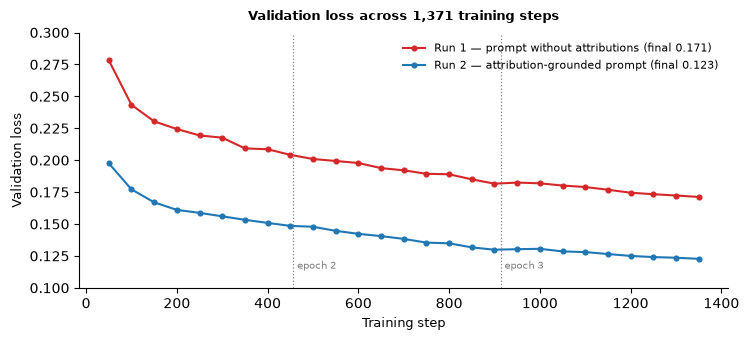

In [ ]:
#72
steps = np.arange(50, 1400, 50)
run1 = [0.278278,0.243353,0.230387,0.224411,0.219383,0.217622,0.209240,0.208560,
        0.204183,0.200926,0.199383,0.197774,0.193785,0.192054,0.189332,0.188965,
        0.184988,0.181598,0.182439,0.181879,0.180123,0.178975,0.176854,0.174495,
        0.173348,0.172319,0.171190]
run2 = [0.197563,0.177147,0.166973,0.161061,0.158727,0.156023,0.153289,0.150853,
        0.148529,0.147850,0.144644,0.142302,0.140506,0.138339,0.135425,0.134862,
        0.131676,0.129850,0.130274,0.130561,0.128531,0.128002,0.126476,0.124995,
        0.124089,0.123573,0.122721]

fig, ax = plt.subplots(figsize=(7.6, 3.5))
ax.plot(steps, run1, 'o-', ms=3.4, lw=1.5, color='C3',
        label='Run 1 — prompt without attributions (final 0.171)')
ax.plot(steps, run2, 'o-', ms=3.4, lw=1.5, color='C0',
        label='Run 2 — attribution-grounded prompt (final 0.123)')
for e, lbl in [(457,'epoch 2'), (914,'epoch 3')]:
    ax.axvline(e, ls=':', lw=0.9, color='grey')
    ax.text(e+8, 0.115, lbl, fontsize=7.5, color='grey')
ax.set_xlabel('Training step', fontsize=9)
ax.set_ylabel('Validation loss', fontsize=9)
ax.set_ylim(0.10, 0.30)
ax.legend(frameon=False, fontsize=8, loc='upper right')
ax.spines[['top','right']].set_visible(False)
ax.set_title('Validation loss across 1,371 training steps',
             fontsize=9.5, fontweight='bold', pad=9)
plt.tight_layout()
plt.savefig('outputs/fig5_2_loss.png', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
#73
os.makedirs('models/mistral_fraud_lora_v2', exist_ok=True)
model.save_pretrained('models/mistral_fraud_lora_v2')
tokenizer.save_pretrained('models/mistral_fraud_lora_v2')
print('Saved v2 LoRA adapter and tokenizer')

Saved v2 LoRA adapter and tokenizer


In [ ]:
#74
shap_values_full = np.load('outputs/shap/shap_values_full.npy')
X_test = pd.read_pickle('outputs/shap/X_test_full.pkl')
y_test = pd.read_pickle('outputs/shap/y_test_full.pkl')

with open('ieee-fraud-detection/llm_val_formatted.json', 'r') as f:
    val_formatted = json.load(f)

all_cols = list(X_test.columns)

print("Data loaded.", shap_values_full.shape, len(val_formatted))

Data loaded. (118108, 431) 813


In [ ]:
#75
model_name = "mistralai/Mistral-7B-Instruct-v0.2"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
)

model = PeftModel.from_pretrained(base_model, "models/mistral_fraud_lora_v2")
print("Fine-tuned model loaded.", type(model))

W0907 22:03:37.430000 12196 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

  torch._check_is_size(blocksize)


Fine-tuned model loaded. <class 'peft.peft_model.PeftModelForCausalLM'>


## Phase 5: Generation and evaluation
Greedy decoding, 100-token budget, explicit eos_token_id. Two earlier
configurations were rejected: raising max_new_tokens alone did not stop
repetition, and repetition_penalty=1.3 suppressed repetition but corrupted
numeric values (324.0 rendered as "32 four.0"). The defect was addressed at the
training signal instead (Section 5.3).

In [ ]:
#76
def generate_response(prompt_text, max_new_tokens=100):
    full_prompt = f"<s>[INST] You are a fraud detection assistant. Given the transaction details below, classify the transaction as Fraud or Legitimate, and explain your reasoning based on the key risk factors.\n\n{prompt_text} [/INST]"
    inputs = tokenizer(full_prompt, return_tensors="pt", add_special_tokens=False).to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    
    generated = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    return generated

for sample in val_formatted[:5]:
    full_text = sample['text']
    prompt_section = full_text.split("[/INST]")[0]
    transaction_part = prompt_section.split("Transaction details:")[-1]
    prompt_for_generation = "Transaction details:" + transaction_part
    ground_truth = full_text.split("[/INST]")[1].replace("</s>", "").strip()
    generated = generate_response(prompt_for_generation)
    print("GROUND TRUTH:", ground_truth)
    print("\nMODEL GENERATED:", generated)
    print("\n" + "="*80 + "\n")

  torch._check_is_size(blocksize)


GROUND TRUTH: Classification: Legitimate
Factors decreasing fraud risk: billing region code 324.0; a transaction amount of $44.50; a debit card type; an engineered risk indicator (M5) with value F; an internal card identifier (card2) with value 360.0.

MODEL GENERATED: Classification: Legitimate
Factors decreasing fraud risk: billing region code 324.0; a transaction amount of $44.50; a debit card type; an engineered risk indicator (M5) with value F; an internal card identifier (card2) with value 360.0. Factors decreasing fraud risk include the address information; a transaction amount of $44.50; a debit card type


GROUND TRUTH: Classification: Fraud
Factors increasing fraud risk: an engineered risk indicator (C9) with value 6.0; billing region code 472.0; an engineered risk indicator (V76) with value 3.0; an engineered risk indicator (V54) with value 3.0. Factors decreasing fraud risk: an internal card identifier (card2) with value 385.0.

MODEL GENERATED: Classification: Fraud
Factor

Termination and classification check on 30 validation examples:
76.7% classification accuracy, 40.0% clean stop rate.

In [ ]:
#77
def evaluate_generation(sample):
    full_text = sample['text']
    prompt_section = full_text.split("[/INST]")[0]
    transaction_part = prompt_section.split("Transaction details:")[-1]
    prompt_for_generation = "Transaction details:" + transaction_part
    ground_truth = full_text.split("[/INST]")[1].replace("</s>", "").strip()
    generated = generate_response(prompt_for_generation)

    gt_label = ground_truth.split("\n")[0].replace("Classification:", "").strip()
    gen_label = generated.split("\n")[0].replace("Classification:", "").strip() if "Classification:" in generated else "UNKNOWN"
    
    correct_class = (gt_label == gen_label)
    clean_stop = generated.count("Factors increasing") <= 1 and generated.count("Factors decreasing") <= 1

    return {'correct_classification': correct_class, 'clean_stop': clean_stop, 'generated': generated}

results = []
start = time.time()
for i, s in enumerate(val_formatted[:30]):
    results.append(evaluate_generation(s))
    elapsed = time.time() - start
    print(f"Processed {i+1}/30. Time: {elapsed:.1f}s ({elapsed/(i+1):.1f}s per example)", flush=True)
    
results_df = pd.DataFrame(results)
print(f"\nClassification accuracy: {results_df['correct_classification'].mean()*100:.1f}%")
print(f"Clean stop rate: {results_df['clean_stop'].mean()*100:.1f}%")

Processed 1/30. Time: 11.1s (11.1s per example)
Processed 2/30. Time: 21.6s (10.8s per example)
Processed 3/30. Time: 34.7s (11.6s per example)
Processed 4/30. Time: 47.6s (11.9s per example)
Processed 5/30. Time: 58.5s (11.7s per example)
Processed 6/30. Time: 69.9s (11.7s per example)
Processed 7/30. Time: 81.5s (11.6s per example)
Processed 8/30. Time: 92.7s (11.6s per example)
Processed 9/30. Time: 104.2s (11.6s per example)
Processed 10/30. Time: 114.2s (11.4s per example)
Processed 11/30. Time: 125.1s (11.4s per example)
Processed 12/30. Time: 136.5s (11.4s per example)
Processed 13/30. Time: 147.7s (11.4s per example)
Processed 14/30. Time: 158.5s (11.3s per example)
Processed 15/30. Time: 169.0s (11.3s per example)
Processed 16/30. Time: 179.4s (11.2s per example)
Processed 17/30. Time: 190.6s (11.2s per example)
Processed 18/30. Time: 201.0s (11.2s per example)
Processed 19/30. Time: 211.7s (11.1s per example)
Processed 20/30. Time: 222.2s (11.1s per example)
Processed 21/30. 

In [ ]:
#78
for i, r in enumerate(results):
    if not r['clean_stop']:
        print(f"--- {i} ---")
        print(r['generated'])
        print()

--- 0 ---
Classification: Legitimate
Factors decreasing fraud risk: billing region code 324.0; a transaction amount of $44.50; a debit card type; an engineered risk indicator (M5) with value F; an internal card identifier (card2) with value 360.0. Factors decreasing fraud risk include the address information; a transaction amount of $44.50; a debit card type

--- 2 ---
Classification: Fraud
Factors increasing fraud risk: an engineered risk indicator (D2) with value 1.0; a credit card type; an engineered risk indicator (C13) with value 1.0. Factors decreasing fraud risk: billing region code 325.0; an internal card identifier (card2) with value 361.0. Factors increasing fraud risk can be mitigated by monitoring these

--- 3 ---
Classification: Fraud
Factors increasing fraud risk: browser/user-agent info 'chrome 66.0'; an engineered risk indicator (C14) with value 0.0; an engineered risk indicator (C13) with value 0.0; a credit card type. Factors decreasing fraud risk: device info 'Window

In [ ]:
#79
cols = set(X_test.columns)

for i, r in enumerate(results[:30]):
    if r.get('clean_stop', True):
        continue
    prompt = val_formatted[i]['text'].split("[/INST]")[0]
    given = set(re.findall(r'([A-Za-z_][A-Za-z0-9_]*)\s*\(value:', prompt))
    named = {c for c in cols if re.search(r'\b' + re.escape(c) + r'\b', r['generated'])}
    extra = sorted(named - given)
    print(f"{i:3d}  extra: {extra if extra else 'none'}")

  0  extra: none
  2  extra: none
  3  extra: none
  4  extra: none
  5  extra: none
  6  extra: none
  7  extra: none
 11  extra: none
 13  extra: none
 14  extra: none
 15  extra: none
 18  extra: none
 19  extra: none
 22  extra: none
 24  extra: none
 26  extra: none
 27  extra: none
 29  extra: none


In [ ]:
#80
for i, (sample, r) in enumerate(zip(val_formatted[:30], results)):
    if not r['correct_classification']:
        full_text = sample['text']
        prompt_section = full_text.split("[/INST]")[0]
        ground_truth = full_text.split("[/INST]")[1].replace("</s>", "").strip()
        print(f"--- Misclassified example {i} ---")
        print("PROMPT (risk factors):", prompt_section.split("Model-identified risk factors:")[-1].strip())
        print("GROUND TRUTH:", ground_truth[:100])
        print("GENERATED:", r['generated'][:150])
        print()

--- Misclassified example 2 ---
PROMPT (risk factors): addr1 (value: 325.0) decreases fraud risk; D2 (value: 1.0) increases fraud risk; card6 (value: credit) increases fraud risk; C13 (value: 1.0) increases fraud risk; card2 (value: 361.0) decreases fraud risk.
GROUND TRUTH: Classification: Legitimate
Factors increasing fraud risk: an engineered risk indicator (D2) with val
GENERATED: Classification: Fraud
Factors increasing fraud risk: an engineered risk indicator (D2) with value 1.0; a credit card type; an engineered risk indicato

--- Misclassified example 6 ---
PROMPT (risk factors): C13 (value: 11.0) decreases fraud risk; card2 (value: 555.0) decreases fraud risk; addr1 (value: 512.0) decreases fraud risk; card1 (value: 2753) decreases fraud risk; V70 (value: 1.0) decreases fraud risk.
GROUND TRUTH: Classification: Fraud
Factors decreasing fraud risk: an engineered risk indicator (C13) with value 1
GENERATED: Classification: Legitimate
Factors decreasing fraud risk: an engineered 

Maps validation positions back to original test-set indices for the seven
misclassified cases, giving orig_indices for Figure 6.1.

In [ ]:
#81
prompt_to_index = {}
for ex in training_data:
    key = ex['prompt'].split("Model-identified risk factors:")[0].strip()
    prompt_to_index[key] = ex['index']

def get_original_index(val_sample):
    full_text = val_sample['text']
    prompt_section = full_text.split("[/INST]")[0]
    transaction_part = "Transaction details:" + prompt_section.split("Transaction details:")[-1]
    base_prompt = transaction_part.split("Model-identified risk factors:")[0].strip()
    return prompt_to_index.get(base_prompt, None)

misclassified_positions = [2, 6, 9, 12, 16, 21, 24]
orig_indices = []

for pos in misclassified_positions:
    orig_idx = get_original_index(val_formatted[pos])
    if orig_idx is None:
        print(f"Position {pos}: could not match back to original index")
        continue
    orig_indices.append(orig_idx)
    top10 = get_top_features(orig_idx, X_test, shap_values_full, k=10)
    true_label = "Fraud" if y_test.iloc[orig_idx] == 1 else "Legitimate"
    print(f"\n--- Position {pos} (original index {orig_idx}) | True label: {true_label} ---")
    for feat_name, feat_val, shap_val in top10:
        direction = "increases" if shap_val > 0 else "decreases"
        print(f"  {feat_name}: {feat_val} ({direction} fraud risk, SHAP={shap_val:.3f})")

print("\norig_indices =", orig_indices)


--- Position 2 (original index 100582) | True label: Legitimate ---
  addr1: 325.0 (decreases fraud risk, SHAP=-1.693)
  D2: 1.0 (increases fraud risk, SHAP=0.884)
  card6: credit (increases fraud risk, SHAP=0.672)
  C13: 1.0 (increases fraud risk, SHAP=0.460)
  card2: 361.0 (decreases fraud risk, SHAP=-0.434)
  M4: M0 (decreases fraud risk, SHAP=-0.367)
  V13: 2.0 (increases fraud risk, SHAP=0.320)
  V281: 1.0 (increases fraud risk, SHAP=0.303)
  M3: F (increases fraud risk, SHAP=0.295)
  M9: F (decreases fraud risk, SHAP=-0.292)

--- Position 6 (original index 64427) | True label: Fraud ---
  C13: 11.0 (decreases fraud risk, SHAP=-1.168)
  card2: 555.0 (decreases fraud risk, SHAP=-0.984)
  addr1: 512.0 (decreases fraud risk, SHAP=-0.983)
  card1: 2753 (decreases fraud risk, SHAP=-0.911)
  V70: 1.0 (decreases fraud risk, SHAP=-0.877)
  C1: 8.0 (increases fraud risk, SHAP=0.822)
  TransactionAmt: 107.95 (decreases fraud risk, SHAP=-0.775)
  C9: 6.0 (increases fraud risk, SHAP=0.705)
 

## Faithfulness measurement
Feature names in each generated explanation are matched against the set supplied
in its prompt, with word boundaries so short names do not match as substrings.
Two metrics: fabrication count (named but not supplied) and recall (proportion
of supplied features cited).

In [ ]:
#82
def extract_mentioned_features(generated_text, all_feature_names):
    mentioned = []
    for feat_name in all_feature_names:
        pattern = r'\b' + re.escape(feat_name) + r'\b'
        if re.search(pattern, generated_text):
            mentioned.append(feat_name)
    return mentioned

test_text = "Factors increasing fraud risk: C9 (value: 6.0) increases fraud risk; V76 (value: 3.0) increases fraud risk."
all_cols = list(X_test.columns)
mentioned = extract_mentioned_features(test_text, all_cols)
print(mentioned)

['C9', 'V76']


In [ ]:
#83
full_text = val_formatted[0]['text']
prompt_section = full_text.split("[/INST]")[0]
transaction_part = "Transaction details:" + prompt_section.split("Transaction details:")[-1]

generated = generate_response(transaction_part)
print("PROMPT:", transaction_part)
print("\nGENERATED:", generated)

  torch._check_is_size(blocksize)


PROMPT: Transaction details: billing region code 324.0; a mastercard card; a debit card type; product category 'W'; a transaction amount of $44.50; billing country code 87.0; purchaser email domain 'yahoo.com'. Model-identified risk factors: addr1 (value: 324.0) decreases fraud risk; TransactionAmt (value: 44.5) decreases fraud risk; card6 (value: debit) decreases fraud risk; M5 (value: F) decreases fraud risk; card2 (value: 360.0) decreases fraud risk. 

GENERATED: Classification: Legitimate
Factors decreasing fraud risk: billing region code 324.0; a transaction amount of $44.50; a debit card type; an engineered risk indicator (M5) with value F; an internal card identifier (card2) with value 360.0. Factors decreasing fraud risk include the address information; a transaction amount of $44.50; a debit card type


Only the primary response is scored. Where generation does not terminate
cleanly, the model paraphrases factors it has already cited, so the repeated
material adds no new features.

In [ ]:
#84
def get_primary_response(generated_text):
    """Cut off at the first repeated 'Factors increasing/decreasing' section."""
    markers = ['Factors increasing fraud risk:', 'Factors decreasing fraud risk:']
    positions = []
    for marker in markers:
        start = 0
        while True:
            idx = generated_text.find(marker, start)
            if idx == -1:
                break
            positions.append(idx)
            start = idx + 1
    positions = sorted(positions)
    
    if len(positions) > 2:
        cutoff = positions[2]
        return generated_text[:cutoff].strip()
    return generated_text.strip()


primary = get_primary_response(generated)
print(primary)

Classification: Legitimate
Factors decreasing fraud risk: billing region code 324.0; a transaction amount of $44.50; a debit card type; an engineered risk indicator (M5) with value F; an internal card identifier (card2) with value 360.0. Factors decreasing fraud risk include the address information; a transaction amount of $44.50; a debit card type


In [ ]:
#85
def compute_faithfullness_overlap(sample, all_feature_names, k=5):
    full_text = sample['text']
    prompt_section = full_text.split("[/INST]")[0]
    transaction_part = "Transaction details:" + prompt_section.split("Transaction details:")[-1]

    given_features = extract_mentioned_features(transaction_part, all_feature_names)
    generated = generate_response(transaction_part)
    primary_response = get_primary_response(generated)

    mentioned_features = extract_mentioned_features(primary_response, all_feature_names)

    if len(given_features) == 0:
        return None

    correctly_mentioned = set(mentioned_features) & set(given_features)
    fabricated = set(mentioned_features) - set(given_features)

    return{
        'given_count': len(given_features),
        'mentioned_count': len(mentioned_features),
        'correct_overlap': len(correctly_mentioned),
        'fabricated_count': len(fabricated),
        'recall': len(correctly_mentioned) / len(given_features) if given_features else None,
        'fabricated_features': list(fabricated),
    }

result = compute_faithfullness_overlap(val_formatted[0], all_cols)
print(result)


{'given_count': 5, 'mentioned_count': 2, 'correct_overlap': 2, 'fabricated_count': 0, 'recall': 0.4, 'fabricated_features': []}


Pilot run on 50 examples to check the pipeline end to end.
The reported evaluation is the 200-example run below (#88).

In [ ]:
#86
recordesults = []
start = time.time()
for i, sample in enumerate(val_formatted[:50]):
    r = compute_faithfullness_overlap(sample, all_cols)
    if r is not None:
        r['index'] = i
        recordesults.append(r)
    if (i+1) % 10 == 0:
        print(f"Processed {i+1}/50. Time: {time.time()-start:.1f}s")

results_df = pd.DataFrame(recordesults)
print(f"\nMean recall: {results_df['recall'].mean():.3f}")
print(f"% with zero fabrication: {(results_df['fabricated_count']==0).mean()*100:.1f}%")
print(f"Mean fabricated features per example: {results_df['fabricated_count'].mean():.2f}")

Processed 10/50. Time: 113.7s
Processed 20/50. Time: 216.8s
Processed 30/50. Time: 324.8s
Processed 40/50. Time: 428.1s
Processed 50/50. Time: 536.3s

Mean recall: 0.628
% with zero fabrication: 98.0%
Mean fabricated features per example: 0.02


In [ ]:
#87
low_recall = results_df[results_df['recall'] < 0.6].sort_values('recall')
print(f"Examples with recall < 0.6: {len(low_recall)} out of {len(results_df)}")
print(low_recall[['index', 'given_count', 'mentioned_count', 'recall']])

Examples with recall < 0.6: 14 out of 50
    index  given_count  mentioned_count  recall
7       7            5                1     0.2
35     35            5                1     0.2
3       3            5                2     0.4
0       0            5                2     0.4
9       9            5                2     0.4
15     15            5                2     0.4
19     19            5                2     0.4
5       5            5                2     0.4
21     21            5                2     0.4
26     26            5                2     0.4
30     30            5                2     0.4
34     34            5                2     0.4
37     37            5                2     0.4
45     45            5                2     0.4


Full evaluation, 200 validation examples. These are the figures reported
throughout Chapter 5: mean recall 0.633, 99.5% with zero fabrication,
0.01 fabricated features per explanation.

In [ ]:
#88
results_large = []
start = time.time()
for i, sample in enumerate(val_formatted[:200]):
    r = compute_faithfullness_overlap(sample, all_cols)
    if r is not None:
        r['index'] = i
        results_large.append(r)
    if (i+1) % 25 == 0:
        print(f"Processed {i+1}/200. Time: {time.time()-start:.1f}s")

results_large_df = pd.DataFrame(results_large)
print(f"\nMean recall: {results_large_df['recall'].mean():.3f}")
print(f"% with zero fabrication: {(results_large_df['fabricated_count']==0).mean()*100:.1f}%")
print(f"Mean fabricated features per example: {results_large_df['fabricated_count'].mean():.2f}")

results_large_df.to_csv('outputs/faithfulness_eval_200.csv', index=False)
print("Saved.")

  torch._check_is_size(blocksize)


Processed 25/200. Time: 269.9s
Processed 50/200. Time: 537.7s
Processed 75/200. Time: 811.7s
Processed 100/200. Time: 1081.4s
Processed 125/200. Time: 1349.4s
Processed 150/200. Time: 1614.5s
Processed 175/200. Time: 1886.1s
Processed 200/200. Time: 2152.6s

Mean recall: 0.633
% with zero fabrication: 99.5%
Mean fabricated features per example: 0.01
Saved.


## Counterfactual perturbation test
TransactionAmt multiplied by twenty, attributions recomputed, explanation
regenerated. Tests whether generation follows the supplied attributions or the
surface salience of the input (Atanasova et al., 2023; Section 5.6).

In [ ]:
#89
test_idx = np.where(y_test.values == 1)[0][10] 
original_row = X_test.iloc[test_idx].copy()

print("Original TransactionAmt:", original_row['TransactionAmt'])
print("Original top-5 SHAP features:")
for feat_name, feat_val, shap_val in get_top_features(test_idx, X_test, shap_values_full, k=5):
    print(f"  {feat_name}: {feat_val} (SHAP={shap_val:.3f})")

Original TransactionAmt: 12.436
Original top-5 SHAP features:
  V62: 5.0 (SHAP=1.364)
  C11: 4.0 (SHAP=1.034)
  D13: 6.0 (SHAP=-0.880)
  id_31: chrome 65.0 (SHAP=0.791)
  card2: 142.0 (SHAP=0.785)


In [ ]:
#90
perturbed_row = original_row.copy()
original_amt = perturbed_row['TransactionAmt']
perturbed_row['TransactionAmt'] = original_amt * 20  

print(f"Original amount: {original_amt}")
print(f"Perturbed amount: {perturbed_row['TransactionAmt']}")

Original amount: 12.436
Perturbed amount: 248.72


In [ ]:
#91
final_model = xgb.XGBClassifier()
final_model.load_model('models/xgb_baseline.json')

explainer = shap.TreeExplainer(final_model)
print("Reloaded final_model and explainer")

Reloaded final_model and explainer


In [ ]:
#92
perturbed_df = pd.DataFrame([perturbed_row])

for col in X_test.columns:
    if X_test[col].dtype.name == 'category':
        perturbed_df[col] = pd.Categorical(perturbed_df[col], categories=X_test[col].cat.categories)

new_proba = final_model.predict_proba(perturbed_df)[:, 1][0]
original_proba = final_model.predict_proba(X_test.iloc[[test_idx]])[:, 1][0]

print(f"Original fraud probability: {original_proba:.4f}")
print(f"Perturbed fraud probability: {new_proba:.4f}")

new_shap = explainer.shap_values(perturbed_df)
print("\nPerturbed top-5 SHAP features:")
perturbed_top = get_top_features(0, perturbed_df, new_shap, k=5)
for feat_name, feat_val, shap_val in perturbed_top:
    print(f"  {feat_name}: {feat_val} (SHAP={shap_val:.3f})")

Original fraud probability: 0.9955
Perturbed fraud probability: 0.9874

Perturbed top-5 SHAP features:
  V62: 5.0 (SHAP=1.296)
  C11: 4.0 (SHAP=1.104)
  D13: 6.0 (SHAP=-0.830)
  C6: 5.0 (SHAP=0.684)
  DeviceInfo: Windows (SHAP=-0.487)


In [ ]:
#93

def build_perturbed_prompt(perturbed_df, new_shap, nameable_set, k=5):
    row_as_series = perturbed_df.iloc[0]
    
    parts = []
    for feat_name in nameable_set:
        if feat_name in perturbed_df.columns:
            val = row_as_series[feat_name]
            if pd.notna(val) and str(val) not in ('nan', 'missing_value'):
                parts.append(describe_feature(feat_name, val))
    base_prompt = "Transaction details: " + "; ".join(parts) + "."
    
    top_feats = get_top_features(0, perturbed_df, new_shap, k=k)
    attribution_lines = []
    for feat_name, feat_val, shap_val in top_feats:
        direction = "increases" if shap_val > 0 else "decreases"
        if feat_val in ('missing_value', 'nan') or pd.isna(feat_val):
            display_val = "missing/undisclosed"
        else:
            display_val = feat_val
        attribution_lines.append(f"{feat_name} (value: {display_val}) {direction} fraud risk")
    
    attributions_text = "Model-identified risk factors: " + "; ".join(attribution_lines) + "."
    return base_prompt + " " + attributions_text

perturbed_prompt = build_perturbed_prompt(perturbed_df, new_shap, nameable_set)
print("PERTURBED PROMPT:", perturbed_prompt)

perturbed_generated = generate_response(perturbed_prompt)
print("\nGENERATED:", perturbed_generated)

PERTURBED PROMPT: Transaction details: recipient email domain 'gmail.com'; device info 'Windows'; purchaser email domain 'gmail.com'; a debit card type; product category 'C'; a transaction amount of $248.72; device type 'desktop'; a visa card. Model-identified risk factors: V62 (value: 5.0) increases fraud risk; C11 (value: 4.0) increases fraud risk; D13 (value: 6.0) decreases fraud risk; C6 (value: 5.0) increases fraud risk; DeviceInfo (value: Windows) decreases fraud risk.


  torch._check_is_size(blocksize)



GENERATED: Classification: Fraud
Factors increasing fraud risk: an engineered risk indicator (V62) with value 5.0; an engineered risk indicator (C11) with value 4.0; an engineered risk indicator (C6) with value 5.0. Factors decreasing fraud risk: an engineered risk indicator (D13) with value 6.0; device info 'Windows'.


## ISO/IEC 42001 rubric
Two computable quantities mapped to rubric criteria: fabrication count to
traceability, attribution recall to completeness (Table 6.1).
Results: traceability 2.00/2, completeness 1.34/2.

In [ ]:
#94
def score_iso_rubric(row):
    # Criterion 1: Traceability
    traceability = 2 if row['fabricated_count'] == 0 else (1 if row['fabricated_count'] <= 2 else 0)
    
    # Criterion 2: Completeness
    if row['recall'] >= 0.8:
        completeness = 2
    elif row['recall'] >= 0.4:
        completeness = 1
    else:
        completeness = 0
    
    return pd.Series({'traceability_score': traceability, 'completeness_score': completeness})

results_large_df[['traceability_score', 'completeness_score']] = results_large_df.apply(score_iso_rubric, axis=1)

print("Traceability score distribution:")
print(results_large_df['traceability_score'].value_counts().sort_index())
print("\nCompleteness score distribution:")
print(results_large_df['completeness_score'].value_counts().sort_index())
print(f"\nMean traceability: {results_large_df['traceability_score'].mean():.2f} / 2")
print(f"Mean completeness: {results_large_df['completeness_score'].mean():.2f} / 2")

Traceability score distribution:
traceability_score
1      1
2    199
Name: count, dtype: int64

Completeness score distribution:
completeness_score
0      8
1    116
2     76
Name: count, dtype: int64

Mean traceability: 2.00 / 2
Mean completeness: 1.34 / 2


In [ ]:
#95
def check_classification_consistency(row, val_formatted_subset):
    # Extract ground truth and generated classification from the stored data
    sample = val_formatted_subset[row['index']]
    full_text = sample['text']
    ground_truth = full_text.split("[/INST]")[1].replace("</s>", "").strip()
    gt_label = ground_truth.split("\n")[0].replace("Classification:", "").strip()
    
    generated = row['generated'] if 'generated' in row else None
    if generated is None:
        return None
    gen_label = generated.split("\n")[0].replace("Classification:", "").strip() if "Classification:" in generated else "UNKNOWN"
    return gt_label == gen_label

In [ ]:
#96
print(results_large_df.columns.tolist())

['given_count', 'mentioned_count', 'correct_overlap', 'fabricated_count', 'recall', 'fabricated_features', 'index', 'traceability_score', 'completeness_score']


In [ ]:
#97
with open('outputs/shap/fraud_tier_map.pkl', 'rb') as f:
    fraud_tier_map = pickle.load(f)

# Map tier to a score: high=2, medium=1, low=0 (low = relies heavily on opaque features)
tier_score_map = {'high': 2, 'medium': 1, 'low': 0}

In [ ]:
#98
def interpretability_tier_from_count(nameable_count):
    if nameable_count == 0:
        return 0
    elif nameable_count <= 2:
        return 1
    else:
        return 2

## Residual fabrication
One explanation in 200 named a feature not supplied (match indicator M6).
At n=1 no analysis of which features are preferentially fabricated is
statistically meaningful (Section 5.8).

In [ ]:
#99
df = pd.read_csv('outputs/faithfulness_eval_200.csv')

df['fab_list'] = df['fabricated_features'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') else []
)

fab_cases = df[df['fabricated_count'] > 0]
print(f"Cases with fabrication: {len(fab_cases)} of {len(df)} ({len(fab_cases)/len(df)*100:.1f}%)")
print(f"\nDistribution of fabrication counts:")
print(fab_cases['fabricated_count'].value_counts().sort_index())

all_fab = [f for lst in df['fab_list'] for f in lst]
print(f"\nTotal fabricated feature instances: {len(all_fab)}")
print(f"\nMost frequently fabricated features:")
for feat, n in Counter(all_fab).most_common(15):
    print(f"  {feat}: {n}")

Cases with fabrication: 1 of 200 (0.5%)

Distribution of fabrication counts:
fabricated_count
1    1
Name: count, dtype: int64

Total fabricated feature instances: 1

Most frequently fabricated features:
  M6: 1


In [ ]:
#100
def fab_category(feat):
    if feat in ('card1','card2','card3','card5'):
        return 'Internal identifier'
    elif feat.startswith('id_'):
        return 'Identity/device feature'
    elif feat.startswith('V'):
        return 'Vesta engineered (V)'
    elif feat.startswith('C'):
        return 'Count feature (C)'
    elif feat.startswith('D'):
        return 'Time-delta feature (D)'
    elif feat.startswith('M'):
        return 'Match indicator (M)'
    else:
        return 'Human-readable'

cats = Counter(fab_category(f) for f in all_fab)
print("\nFabrication by feature category:")
for c, n in cats.most_common():
    print(f"  {c}: {n} ({n/len(all_fab)*100:.1f}%)")

print(f"\nUnique features ever fabricated: {len(set(all_fab))}")


Fabrication by feature category:
  Match indicator (M): 1 (100.0%)

Unique features ever fabricated: 1


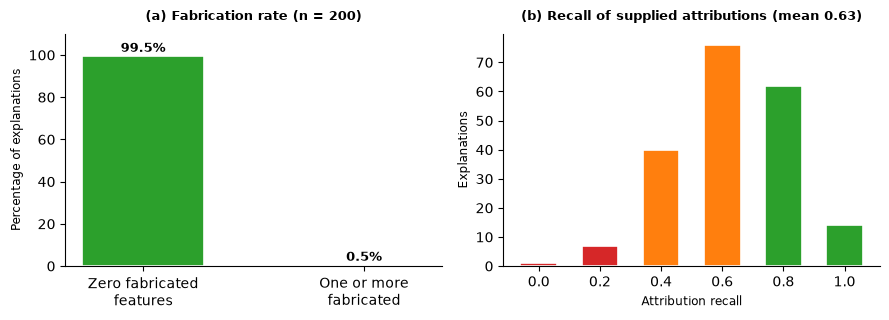

In [ ]:
#101
fab_df = pd.read_csv('outputs/faithfulness_eval_200.csv')

zero_fab = 100*(fab_df['fabricated_count']==0).mean()
rec = fab_df['recall'].round(1).value_counts().sort_index()

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 3.3))

a1.bar(['Zero fabricated\nfeatures','One or more\nfabricated'],
       [zero_fab, 100-zero_fab], width=0.55, color=['C2','C3'],
       edgecolor='white', linewidth=1.2)
for i, v in enumerate([zero_fab, 100-zero_fab]):
    a1.text(i, v+2, f'{v:.1f}%', ha='center', fontsize=9.5, fontweight='bold')
a1.set_ylim(0, 110); a1.set_ylabel('Percentage of explanations', fontsize=8.5)
a1.set_title(f'(a) Fabrication rate (n = {len(fab_df)})', fontsize=9, fontweight='bold', pad=10)
a1.spines[['top','right']].set_visible(False)

cols = ['C3' if r<0.4 else ('C1' if r<0.8 else 'C2') for r in rec.index]
a2.bar([f'{r:.1f}' for r in rec.index], rec.values, width=0.6,
       color=cols, edgecolor='white', linewidth=1.2)
a2.set_xlabel('Attribution recall', fontsize=8.5)
a2.set_ylabel('Explanations', fontsize=8.5)
a2.set_title(f'(b) Recall of supplied attributions (mean {fab_df["recall"].mean():.2f})',
             fontsize=9, fontweight='bold', pad=10)
a2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/fig5_3_faithfulness.png', dpi=200, bbox_inches='tight')
plt.show()

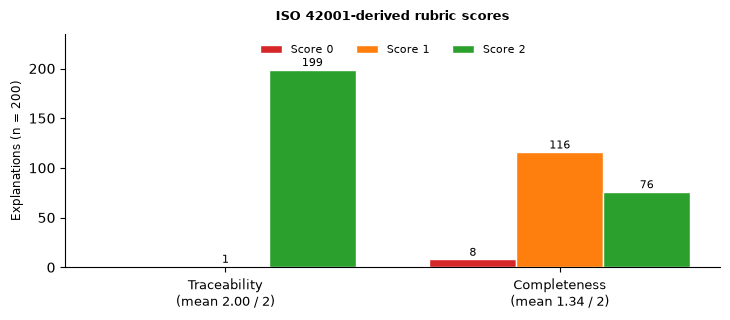

In [ ]:
#102
fab_df['traceability_score'] = fab_df['fabricated_count'].apply(
    lambda c: 2 if c==0 else (1 if c<=2 else 0))
fab_df['completeness_score'] = fab_df['recall'].apply(
    lambda r: 2 if r>=0.8 else (1 if r>=0.4 else 0))

tr = fab_df['traceability_score'].value_counts().reindex([0,1,2], fill_value=0)
co = fab_df['completeness_score'].value_counts().reindex([0,1,2], fill_value=0)

fig, ax = plt.subplots(figsize=(7.4, 3.3))
x = np.arange(2); w = 0.26
for k, (s, colr) in enumerate(zip([0,1,2], ['C3','C1','C2'])):
    vals = [tr[s], co[s]]
    ax.bar(x + (k-1)*w, vals, w, label=f'Score {s}', color=colr, edgecolor='white')
    for xi, v in zip(x, vals):
        if v: ax.text(xi+(k-1)*w, v+3.5, str(v), ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([f'Traceability\n(mean {fab_df["traceability_score"].mean():.2f} / 2)',
                    f'Completeness\n(mean {fab_df["completeness_score"].mean():.2f} / 2)'], fontsize=9)
ax.set_ylabel(f'Explanations (n = {len(fab_df)})', fontsize=8.5)
ax.set_ylim(0, max(tr.max(), co.max())*1.18)
ax.legend(frameon=False, fontsize=8, ncol=3, loc='upper center')
ax.spines[['top','right']].set_visible(False)
ax.set_title('ISO 42001-derived rubric scores', fontsize=9.5, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('outputs/fig5_5_rubric.png', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
#103
space = {
    'Internal identifier': 4,      # card1, card2, card3, card5
    'Match indicator (M)': 9,      # M1-M9
    'Count feature (C)': 14,       # C1-C14
    'Time-delta feature (D)': 15,  # D1-D15
    'Vesta engineered (V)': 339,   # V1-V339
    'Identity/device feature': 38, # id_01-id_38
    'Human-readable': 12,
}
total_feats = sum(space.values())

print(f"{'Category':<26}{'% of space':>12}{'% of fabs':>12}{'ratio':>10}")
for cat, n_space in sorted(space.items(), key=lambda kv: -cats.get(kv[0], 0)):
    pct_space = 100 * n_space / total_feats
    pct_fab = 100 * cats.get(cat, 0) / len(all_fab)
    ratio = pct_fab / pct_space if pct_space else 0
    print(f"{cat:<26}{pct_space:>11.1f}%{pct_fab:>11.1f}%{ratio:>9.1f}x")

Category                    % of space   % of fabs     ratio
Match indicator (M)               2.1%      100.0%     47.9x
Internal identifier               0.9%        0.0%      0.0x
Count feature (C)                 3.2%        0.0%      0.0x
Time-delta feature (D)            3.5%        0.0%      0.0x
Vesta engineered (V)             78.7%        0.0%      0.0x
Identity/device feature           8.8%        0.0%      0.0x
Human-readable                    2.8%        0.0%      0.0x


In [ ]:
#104
with open('ieee-fraud-detection/llm_training_data.json') as f:
    train_data = json.load(f)
train_feat_counts = Counter()
for ex in train_data:
    attr_part = ex['prompt'].split('Model-identified risk factors:')[-1]
    for feat in re.findall(r'([A-Za-z_]+\d*)\s*\(value:', attr_part):
        train_feat_counts[feat] += 1

print("Most frequently ATTRIBUTED features in training corpus:")
for feat, n in train_feat_counts.most_common(15):
    print(f"  {feat}: {n} ({100*n/len(train_data):.1f}% of examples)")

print("\nFeature-by-feature comparison:")
print(f"{'Feature':<16}{'train freq':>12}{'fabricated':>12}")
for feat, nfab in Counter(all_fab).most_common():
    print(f"{feat:<16}{train_feat_counts.get(feat,0):>12}{nfab:>12}")

Most frequently ATTRIBUTED features in training corpus:
  addr1: 5564 (68.5% of examples)
  TransactionAmt: 3937 (48.4% of examples)
  card1: 3358 (41.3% of examples)
  C13: 3334 (41.0% of examples)
  card2: 2549 (31.4% of examples)
  P_emaildomain: 1698 (20.9% of examples)
  id_31: 1659 (20.4% of examples)
  card6: 1513 (18.6% of examples)
  C1: 1463 (18.0% of examples)
  C11: 1197 (14.7% of examples)
  V258: 1050 (12.9% of examples)
  dist1: 998 (12.3% of examples)
  C14: 886 (10.9% of examples)
  D15: 777 (9.6% of examples)
  V70: 725 (8.9% of examples)

Feature-by-feature comparison:
Feature           train freq  fabricated
M6                       289           1


In [ ]:
#105

eval_subset = val_formatted[:200]

supplied_counts = Counter()
for sample in eval_subset:
    attr_part = sample['text'].split('[/INST]')[0].split('Model-identified risk factors:')[-1]
    for feat in set(re.findall(r'([A-Za-z_]+\d*)\s*\(value:', attr_part)):
        supplied_counts[feat] += 1

n_eval = len(eval_subset)
fab_counts = Counter(all_fab)

print(f"{'Feature':<16}{'supplied':>10}{'opportunities':>15}{'fabricated':>12}{'rate':>9}")
rows = []
for feat, nfab in fab_counts.most_common():
    supplied = supplied_counts.get(feat, 0)
    opportunities = n_eval - supplied
    rate = 100 * nfab / opportunities if opportunities else 0
    rows.append((feat, supplied, opportunities, nfab, rate))
for r in sorted(rows, key=lambda x: -x[4]):
    print(f"{r[0]:<16}{r[1]:>10}{r[2]:>15}{r[3]:>12}{r[4]:>8.1f}%")

Feature           supplied  opportunities  fabricated     rate
M6                       8            192           1     0.5%


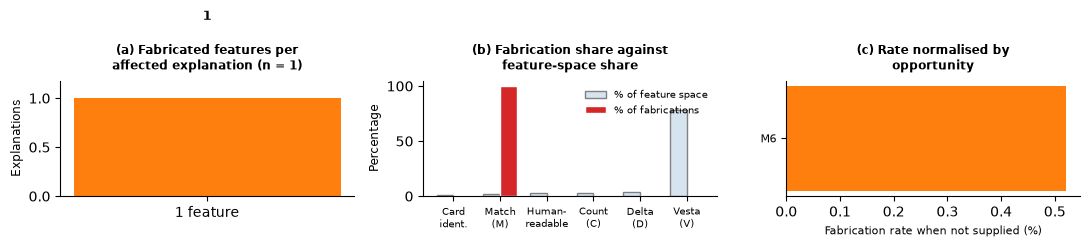

In [ ]:
#106
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(11, 3.3))

fc = fab_cases['fabricated_count'].value_counts().sort_index()
a1.bar([f'{i} feature' + ('s' if i>1 else '') for i in fc.index], fc.values,
       color=['C1','C3'][:len(fc)], width=0.5)
for i, v in enumerate(fc.values):
    a1.text(i, v+0.8, str(v), ha='center', fontsize=9.5, fontweight='bold')
a1.set_ylabel('Explanations', fontsize=8.5); a1.set_ylim(0, fc.max()*1.18)
a1.set_title(f'(a) Fabricated features per\naffected explanation (n = {fc.sum()})',
             fontsize=8.8, fontweight='bold', pad=8)
a1.spines[['top','right']].set_visible(False)

order = ['Internal identifier','Match indicator (M)','Human-readable',
         'Count feature (C)','Time-delta feature (D)','Vesta engineered (V)']
short = ['Card\nident.','Match\n(M)','Human-\nreadable','Count\n(C)','Delta\n(D)','Vesta\n(V)']
sp = [100*space[c]/total_feats for c in order]
fb = [100*cats.get(c,0)/len(all_fab) for c in order]
x = np.arange(len(order)); w = 0.36
a2.bar(x-w/2, sp, w, label='% of feature space', color='#D6E4F0', edgecolor='grey')
a2.bar(x+w/2, fb, w, label='% of fabrications', color='C3', edgecolor='white')
a2.set_xticks(x); a2.set_xticklabels(short, fontsize=7.2)
a2.set_ylabel('Percentage', fontsize=8.5); a2.legend(frameon=False, fontsize=7.4)
a2.set_title('(b) Fabrication share against\nfeature-space share',
             fontsize=8.8, fontweight='bold', pad=8)
a2.spines[['top','right']].set_visible(False)

top = sorted(rows, key=lambda r: -r[4])[:9]
names = [r[0] for r in top]; rts = [r[4] for r in top]
cols = ['C3' if n.startswith('card') else ('C1' if n.startswith('M') else 'C0') for n in names]
a3.barh(range(len(names))[::-1], rts, color=cols, height=0.6)
a3.set_yticks(range(len(names))[::-1]); a3.set_yticklabels(names, fontsize=7.6)
a3.set_xlabel('Fabrication rate when not supplied (%)', fontsize=8)
a3.set_title('(c) Rate normalised by\nopportunity', fontsize=8.8, fontweight='bold', pad=8)
a3.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/fig5_6_fabrication.png', dpi=200, bbox_inches='tight')
plt.show()

Figure 6.1: direction of ranked attributions for the seven misclassified cases
at k=5 and k=10. Four were genuine fraud despite most ranked features pointing
toward legitimacy at both depths.

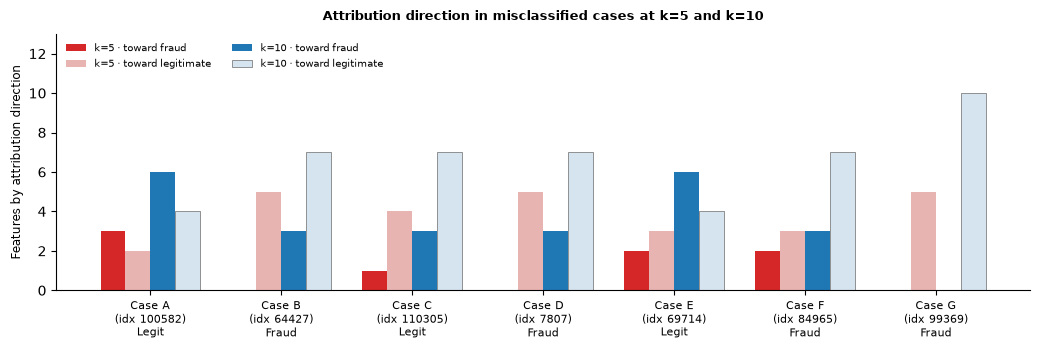

In [ ]:
#107
case_idx = orig_indices
labels = [f'Case {c}\n(idx {i})\n{"Fraud" if y_test.iloc[i]==1 else "Legit"}'
          for c, i in zip('ABCDEFG', case_idx)]

def direction_counts(idx, k):
    feats = get_top_features(idx, X_test, shap_values_full, k=k)
    pos = sum(1 for _, _, s in feats if s > 0)
    return pos, k - pos

k5  = [direction_counts(i, 5)  for i in case_idx]
k10 = [direction_counts(i, 10) for i in case_idx]

x = np.arange(len(case_idx)); w = 0.19
fig, ax = plt.subplots(figsize=(10.5, 3.6))
ax.bar(x-1.5*w, [a for a, _ in k5],  w, color='C3',      label='k=5 · toward fraud')
ax.bar(x-0.5*w, [b for _, b in k5],  w, color='#E8B4B2', label='k=5 · toward legitimate')
ax.bar(x+0.5*w, [a for a, _ in k10], w, color='C0',      label='k=10 · toward fraud')
ax.bar(x+1.5*w, [b for _, b in k10], w, color='#D6E4F0', edgecolor='grey', lw=0.6,
       label='k=10 · toward legitimate')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=7.6)
ax.set_ylabel('Features by attribution direction', fontsize=8.5)
ax.legend(frameon=False, fontsize=7.4, ncol=2, loc='upper left')
ax.set_ylim(0, 13)
ax.spines[['top','right']].set_visible(False)
ax.set_title('Attribution direction in misclassified cases at k=5 and k=10',
             fontsize=9.5, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('outputs/fig6_1_completeness.png', dpi=200, bbox_inches='tight')
plt.show()